## **Histopathological Image Classification of Colon Cancer**

Tamar Levitan & Ayelet Yehezkel

In [ ]:

import os
import random


import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split


from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score
)

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)


from tensorflow.keras.applications import VGG16

from tensorflow.keras.applications.vgg16 import preprocess_input


from tensorflow.keras.utils import to_categorical

import tensorflow as tf

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Input,
    Dense
)

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
# Set a random seed for reproducibility


# Using the same seed helps us get consistent results
# every time we run the notebook. This is useful for
# data splitting, random sampling, and model training.

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:

# Connect to Google Drive
from google.colab import drive

# Mount Google Drive so we can access the project files
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

# Extract the dataset
import zipfile
import os
# Path to the ZIP file stored in Google Drive
zip_path = "/content/drive/MyDrive/ML project/Kather_texture_2016_image_tiles_5000.zip"
# Folder where the dataset will be extracted
extract_path = "/content/dataset"
# Extract all files from the ZIP archive
with zipfile.ZipFile(zip_path, "r") as zip_file:
    zip_file.extractall(extract_path)
print("Dataset extracted successfully!")
# Check that the dataset was extracted correctly
os.listdir(extract_path)

Dataset extracted successfully!


['Kather_texture_2016_image_tiles_5000']

In [ ]:

# Check the dataset folder
dataset_folder = os.path.join(
    extract_path,
    "Kather_texture_2016_image_tiles_5000"
)
# Show the folders inside the dataset directory
os.listdir(dataset_folder)

['06_MUCOSA',
 '08_EMPTY',
 '07_ADIPOSE',
 '01_TUMOR',
 '02_STROMA',
 '04_LYMPHO',
 '05_DEBRIS',
 '03_COMPLEX']

## Create the Dataset Metadata Table

In this step, we scan the dataset directory and create a metadata table containing all image paths and their corresponding class labels.

Each row in the table represents a single image and includes its full file path, its numerical label, and its class name. This DataFrame will serve as the foundation for all subsequent stages of the project.

In [ ]:
# Build a table with all images and their labels
# Path to the dataset folder
dataset_path = "/content/dataset/Kather_texture_2016_image_tiles_5000"

# Get the class names and sort them alphabetically
class_names = sorted(os.listdir(dataset_path))
# Store all image information here
dataset_records = []
# Go through each class folder
for label, class_name in enumerate(class_names):
    # Path to the current class folder
    class_folder = os.path.join(dataset_path, class_name)
    # Skip anything that is not a folder
    if not os.path.isdir(class_folder):
        continue
    # Go through all images in the current class
    for image_name in os.listdir(class_folder):
        # Full path to the image
        image_path = os.path.join(class_folder, image_name)
        # Save the image information
        dataset_records.append({
            "image_path": image_path,
            "label": label,
            "class_name": class_name
        })
# Create a DataFrame with all dataset information
df = pd.DataFrame(dataset_records)
# Show the first few rows
df.head()

,image_path,label,class_name
0,/content/dataset/Kather_texture_2016_image_til...,0,01_TUMOR
1,/content/dataset/Kather_texture_2016_image_til...,0,01_TUMOR
2,/content/dataset/Kather_texture_2016_image_til...,0,01_TUMOR
3,/content/dataset/Kather_texture_2016_image_til...,0,01_TUMOR
4,/content/dataset/Kather_texture_2016_image_til...,0,01_TUMOR


In [ ]:
# Check the dataset
# Show the total number of images
print(f"Number of images: {len(df)}")
# Show the number of classes and their names
print(f"\nNumber of classes: {df['class_name'].nunique()}")
print(df["class_name"].unique())
# Count how many images belong to each class
class_counts = df["class_name"].value_counts().sort_index()
print("\nNumber of images per class:")
print(class_counts)

Number of images: 5000

Number of classes: 8
['01_TUMOR' '02_STROMA' '03_COMPLEX' '04_LYMPHO' '05_DEBRIS' '06_MUCOSA'
 '07_ADIPOSE' '08_EMPTY']

Number of images per class:
class_name
01_TUMOR      625
02_STROMA     625
03_COMPLEX    625
04_LYMPHO     625
05_DEBRIS     625
06_MUCOSA     625
07_ADIPOSE    625
08_EMPTY      625
Name: count, dtype: int64


## Class Distribution

Before training any model, we first check how the images are distributed across the different classes.

This helps us see whether the dataset is balanced or if some classes have many more images than others.

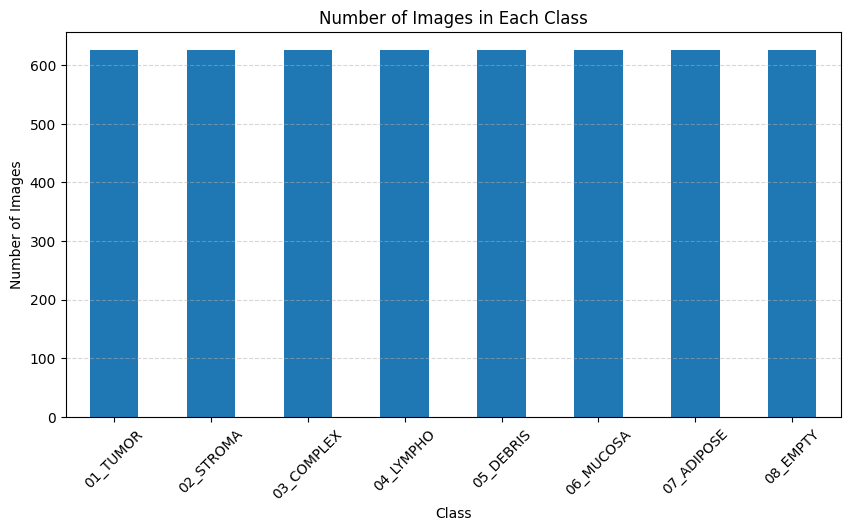

In [ ]:
# Plot the number of images in each class
plt.figure(figsize=(10, 5))
class_counts.plot(kind="bar")
# Add a title and axis labels
plt.title("Number of Images in Each Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
# Rotate the class names to make them easier to read
plt.xticks(rotation=45)
# Add horizontal grid lines
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

## Sample Images

To get a better understanding of the dataset, we display a few random images from each class.

Looking at the images helps us become familiar with the different tissue types before extracting features and training the models.

In [ ]:
def show_sample_images(df, samples_per_class=3):
    """
    Display a few random images from each class.

    Parameters:
        df: DataFrame with the image paths and class names.
        samples_per_class: Number of images to display from each class.
    """
    # Get the class names in alphabetical order
    class_names = sorted(df["class_name"].unique())
    # Create a figure for all sample images
    fig, axes = plt.subplots(
        len(class_names),
        samples_per_class,
        figsize=(12, 22)
    )
    # Go through each class
    for row, class_name in enumerate(class_names):
        # Randomly choose a few images from the current class
        sample_images = df[df["class_name"] == class_name].sample(
            n=samples_per_class,
            random_state=SEED
        )
        # Display the selected images
        for col, (_, image_info) in enumerate(sample_images.iterrows()):
            image = Image.open(image_info["image_path"])
            axes[row, col].imshow(image)
            axes[row, col].axis("off")
        # Show the class name above the middle image
        axes[row, 1].set_title(
            class_name,
            fontsize=12,
            fontweight="bold"
        )
    # Add a title for the whole figure
    plt.suptitle(
        "Sample Images from Each Class",
        fontsize=18,
        fontweight="bold"
    )
    plt.tight_layout()
    plt.show()

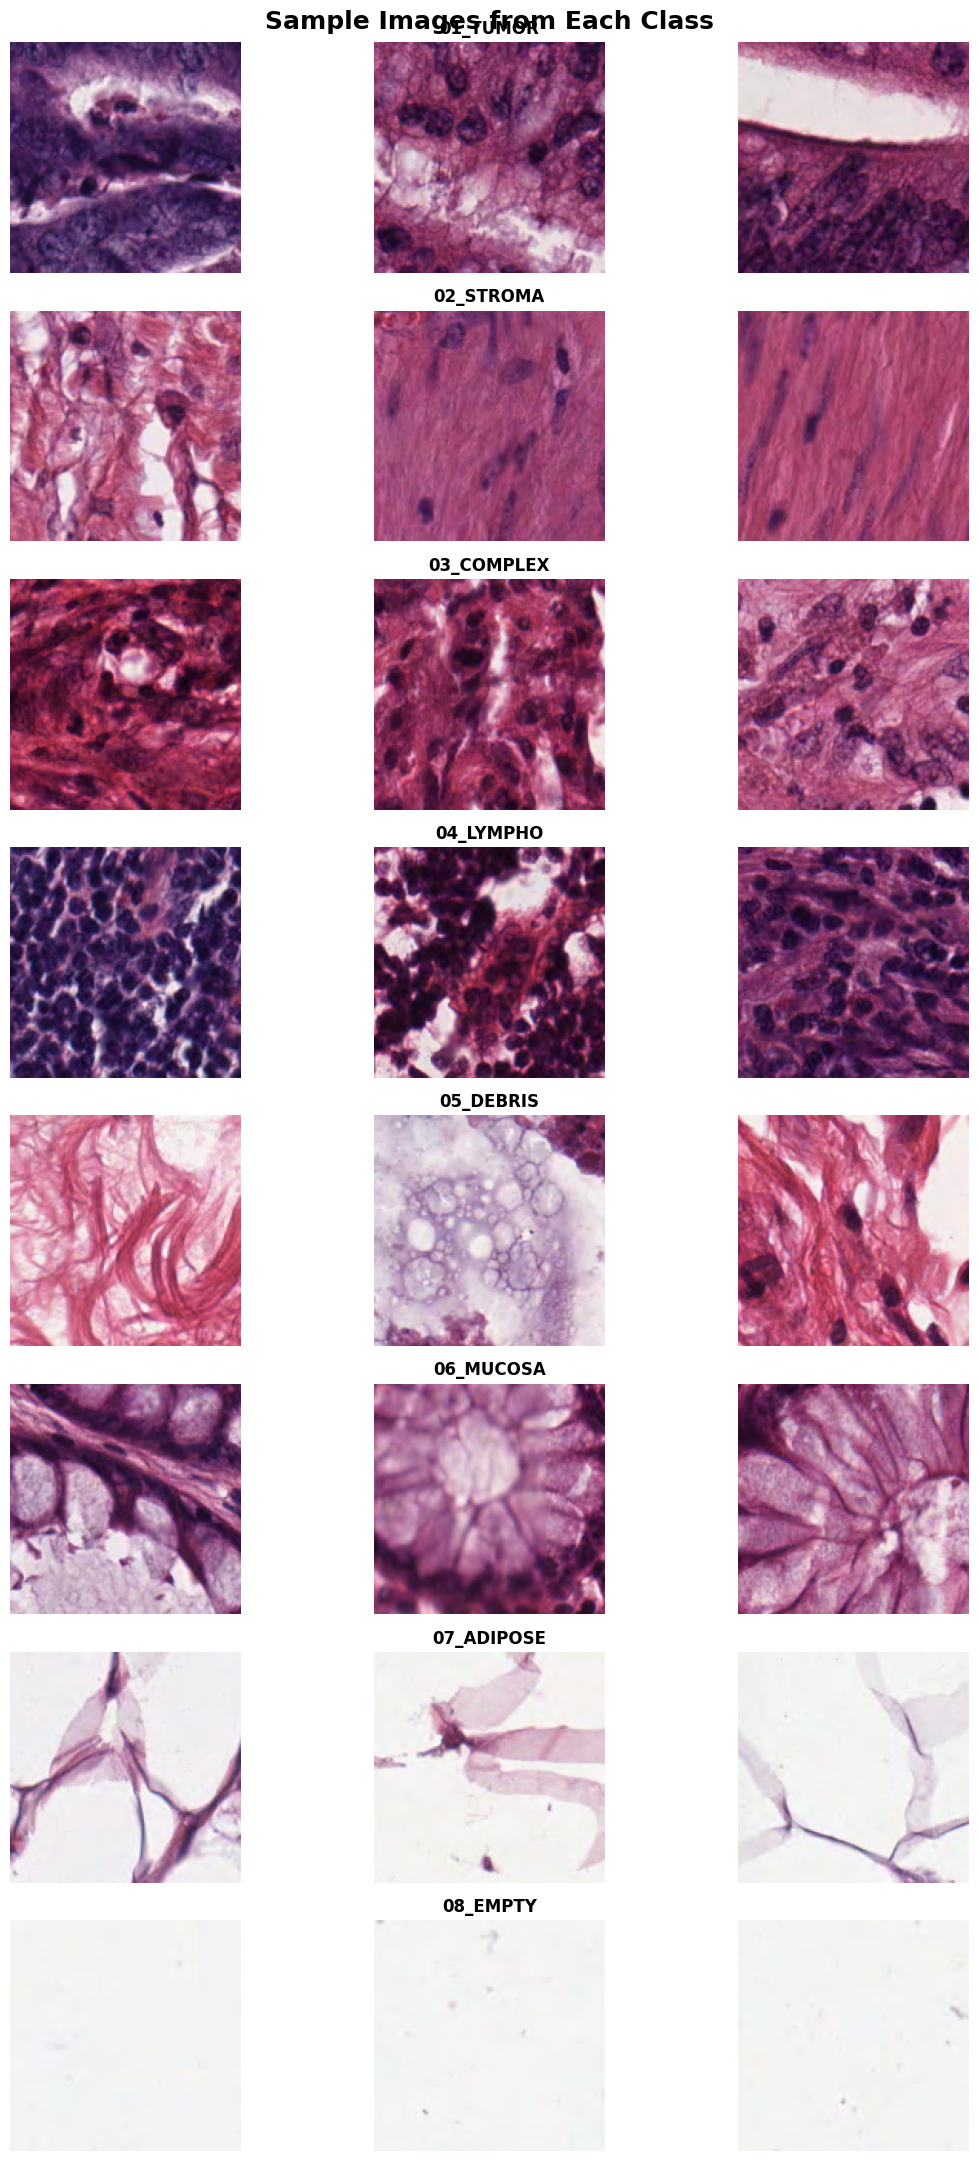

In [ ]:
show_sample_images(df)

## Train-Test Split

We split the dataset into training and test sets using an 80/20 ratio.

We use a stratified split so that both sets keep the same class distribution. This allows us to train the models on one set and evaluate them fairly on unseen data.

In [ ]:
# Split the dataset into training and test sets
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=SEED
)
# Reset the row indices
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [ ]:
# Check the train-test split
# Show the number of images in each set
print(f"Number of training images: {len(train_df)}")
print(f"Number of test images: {len(test_df)}")
# Show the class distribution in the training set
print("\nTraining Set")
print(train_df["class_name"].value_counts().sort_index())
# Show the class distribution in the test set
print("\nTest Set")
print(test_df["class_name"].value_counts().sort_index())

Number of training images: 4000
Number of test images: 1000

Training Set
class_name
01_TUMOR      500
02_STROMA     500
03_COMPLEX    500
04_LYMPHO     500
05_DEBRIS     500
06_MUCOSA     500
07_ADIPOSE    500
08_EMPTY      500
Name: count, dtype: int64

Test Set
class_name
01_TUMOR      125
02_STROMA     125
03_COMPLEX    125
04_LYMPHO     125
05_DEBRIS     125
06_MUCOSA     125
07_ADIPOSE    125
08_EMPTY      125
Name: count, dtype: int64


### Conclusion

The dataset was successfully divided into **4,000 training images** and **1,000 test images**, corresponding to the predefined 80/20 split.

The class distribution was preserved in both subsets, with **500 training images** and **125 test images** for each class. This confirms that the stratified split was performed correctly, ensuring a fair and representative evaluation of the machine learning models.

In [ ]:
def load_images(df):
    # Store the images and labels
    images = []
    labels = []
    # Go through all rows in the DataFrame
    for _, row in df.iterrows():
        # Read the image and convert it to a NumPy array
        image = Image.open(row["image_path"])
        image_array = np.array(image)
        images.append(image_array)
        labels.append(row["label"])
    # Convert the lists to NumPy arrays
    X = np.array(images)
    y = np.array(labels)
    return X, y

In [ ]:
# Load the training images and labels
X_train, y_train = load_images(train_df)
# Check the shape of the loaded data
print(f"Images shape: {X_train.shape}")
print(f"Labels shape: {y_train.shape}")

Images shape: (4000, 150, 150, 3)
Labels shape: (4000,)


## Preparing the Images for PCA

PCA works with two-dimensional data, so each image needs to be converted into a one-dimensional feature vector.

This step keeps all the pixel values but changes the shape of the data so it can be used as input for PCA.

In [ ]:
# Prepare the images for PCA
# Flatten each image into a one-dimensional vector
# so it can be used as input for PCA
X_train_flat = X_train.reshape(
    X_train.shape[0],
    -1
)
# Check the new shape
print(f"Flattened images shape: {X_train_flat.shape}")

Flattened images shape: (4000, 67500)


## PCA Dimensionality Reduction

After flattening the images, we use PCA to reduce the number of features from 67,500 to 50.

This keeps most of the important information while making the data much smaller and easier to visualize with t-SNE.

In [ ]:
# Apply PCA
# Reduce the feature vector from 67,500 values to 50 principal components
pca = PCA(
    n_components=50,
    random_state=SEED
)
# Learn the principal components and transform the training data
X_train_pca = pca.fit_transform(X_train_flat)
# Check the output shape
print(f"PCA output shape: {X_train_pca.shape}")

PCA output shape: (4000, 50)


### Conclusion

PCA successfully reduced the dimensionality of the training data from **67,500** original features to **50 principal components**.

The transformed dataset now has a shape of **(4000, 50)**, providing a compact representation of the images while preserving most of the information contained in the original feature space. This reduced representation is well suited for the subsequent t-SNE visualization.

## t-SNE Visualization

After reducing the data with PCA, we apply t-SNE to project it into two dimensions.

This makes it easier to visualize the data and see whether images from the same class tend to form similar groups.

In [ ]:
# Apply t-SNE
# Reduce the PCA features to two dimensions for visualization
tsne = TSNE(
    n_components=2,
    random_state=SEED,
    perplexity=30
)
# Transform the PCA features into a 2D representation
X_train_tsne = tsne.fit_transform(X_train_pca)
# Check the output shape
print(f"t-SNE output shape: {X_train_tsne.shape}")

t-SNE output shape: (4000, 2)


## t-SNE Visualization

Finally, we visualize the training images in two dimensions using the t-SNE representation.

Each point represents one image, and the colors indicate the different classes. This helps us explore how well the classes are separated in the feature space.

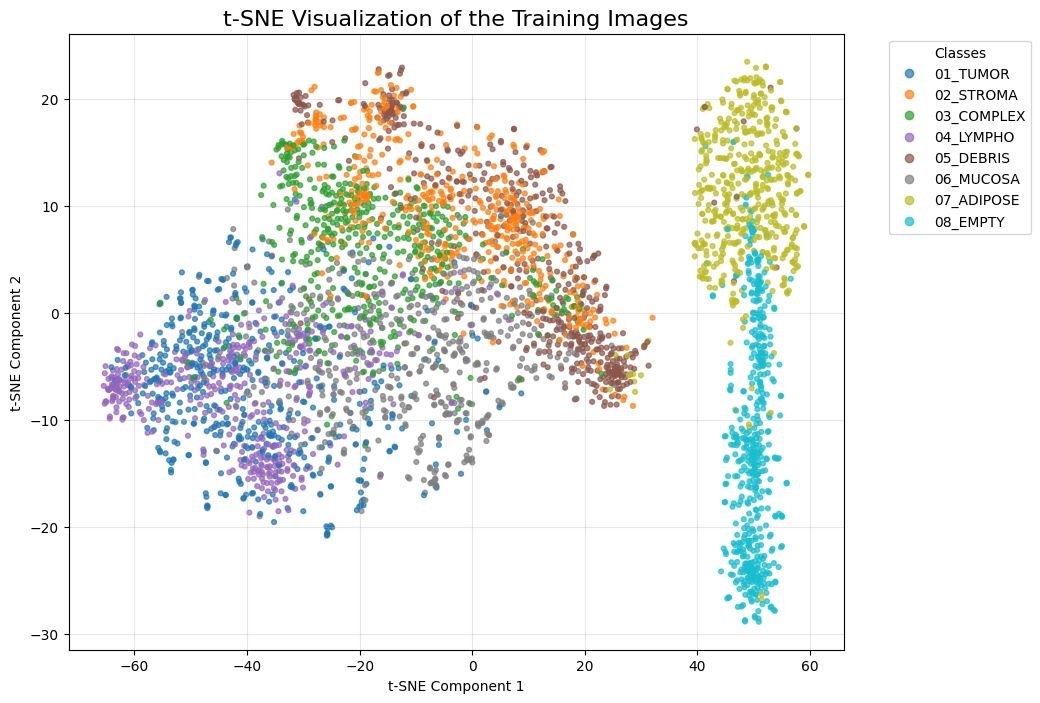

In [ ]:
# Plot the t-SNE visualization
plt.figure(figsize=(10, 8))
# Create the scatter plot
scatter = plt.scatter(
    X_train_tsne[:, 0],
    X_train_tsne[:, 1],
    c=y_train,
    cmap="tab10",
    s=12,
    alpha=0.7
)
# Add a title and axis labels
plt.title("t-SNE Visualization of the Training Images", fontsize=16)
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
# Add a legend for the classes
plt.legend(
    handles=scatter.legend_elements()[0],
    labels=sorted(train_df["class_name"].unique()),
    title="Classes",
    loc="upper left",
    bbox_to_anchor=(1.05, 1)
)
# Add grid lines
plt.grid(alpha=0.3)
plt.show()

### Conclusion

The t-SNE visualization reveals that the dataset contains meaningful cluster structures. In particular, the **ADIPOSE** and **EMPTY** classes form well-separated clusters, indicating that these tissue types have distinct visual characteristics.

In contrast, several other classes exhibit noticeable overlap, especially in the central region of the plot. This suggests that these tissue types share similar texture patterns, making them more challenging to distinguish.

Overall, the visualization indicates that while some classes are naturally well separated, others require more informative feature representations and robust classification models to achieve accurate predictions.

In [ ]:
# Load the test images and labels
X_test, y_test = load_images(test_df)
# Check the shape of the loaded data
print(f"Test images shape: {X_test.shape}")
print(f"Test labels shape: {y_test.shape}")

Test images shape: (1000, 150, 150, 3)
Test labels shape: (1000,)


## Downsample + Flatten Features

The first feature extraction method resizes each image to **32×32** pixels and then flattens it into a one-dimensional vector.

This creates a simple and compact representation of each image that can be used by the classifiers.

In [ ]:
def extract_downsample_features(X_train, X_test):
    # Resize the training images to 32×32 pixels
    X_train_resized = tf.image.resize(X_train, (32, 32)).numpy()
    # Resize the test images to 32×32 pixels
    X_test_resized = tf.image.resize(X_test, (32, 32)).numpy()
    # Flatten each image into a one-dimensional vector
    X_train_features = X_train_resized.reshape(
        len(X_train_resized),
        -1
    )
    X_test_features = X_test_resized.reshape(
        len(X_test_resized),
        -1
    )
    return X_train_features, X_test_features

In [ ]:
# Extract features from the training and test sets
X_train_downsample, X_test_downsample = extract_downsample_features(
    X_train,
    X_test
)
# Check the shape of the extracted features
print(f"Training features shape: {X_train_downsample.shape}")
print(f"Test features shape: {X_test_downsample.shape}")

Training features shape: (4000, 3072)
Test features shape: (1000, 3072)


## Feature Statistics

Before deciding whether normalization is needed, we calculate the mean and standard deviation of each feature in the training set.

These statistics help us understand the distribution and scale of the extracted features.

In [ ]:
# Calculate the mean and standard deviation of each feature
# Mean value of each feature
feature_means = np.mean(
    X_train_downsample,
    axis=0
)
# Standard deviation of each feature
feature_stds = np.std(
    X_train_downsample,
    axis=0
)
# Check the size of the output arrays
print("Means shape:", feature_means.shape)
print("Standard deviations shape:", feature_stds.shape)

Means shape: (3072,)
Standard deviations shape: (3072,)


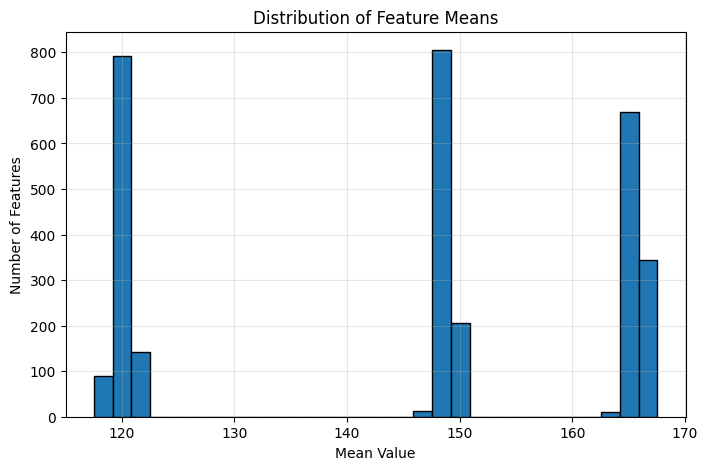

In [ ]:
# Plot the distribution of the feature means
plt.figure(figsize=(8, 5))
plt.hist(
    feature_means,
    bins=30,
    edgecolor="black"
)
# Add a title and axis labels
plt.title("Distribution of Feature Means")
plt.xlabel("Mean Value")
plt.ylabel("Number of Features")
# Add grid lines
plt.grid(alpha=0.3)
plt.show()

### Conclusion

The histogram shows that the feature means are not centered around zero. Instead, the features are grouped into several distinct ranges with different average values.

This indicates that the extracted features have different offsets and are not naturally centered. Therefore, applying feature normalization is expected to improve the consistency of the feature representation before training the machine learning models.

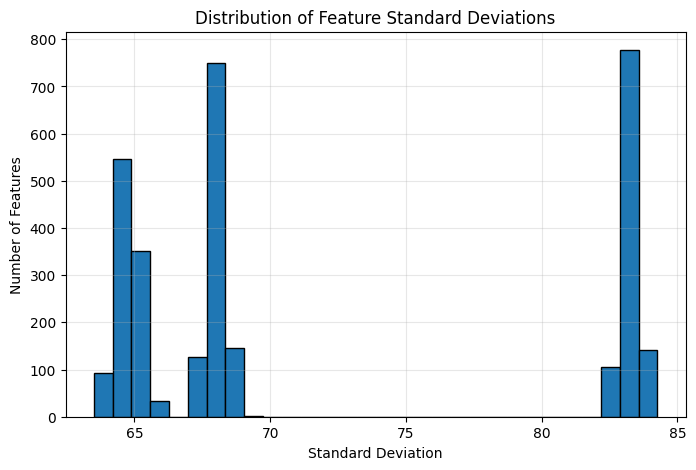

In [ ]:
# Plot the distribution of the feature standard deviations
plt.figure(figsize=(8, 5))
plt.hist(
    feature_stds,
    bins=30,
    edgecolor="black"
)
# Add a title and axis labels
plt.title("Distribution of Feature Standard Deviations")
plt.xlabel("Standard Deviation")
plt.ylabel("Number of Features")
# Add grid lines
plt.grid(alpha=0.3)
plt.show()

### Conclusion

The histogram shows that the standard deviations of the extracted features are distributed across several distinct ranges rather than being concentrated around a single value.

This indicates that the features have different levels of variability and are not measured on a common scale. As a result, feature normalization is necessary to ensure that all features contribute equally during model training and that features with larger variability do not dominate the learning process.

## Feature Normalization

Since the features have different scales, we normalize them using **StandardScaler**.

The scaler is fitted only on the training set and then applied to both the training and test sets. This ensures that no information from the test set is used during training.

In [ ]:
# Normalize the features
# Create a StandardScaler object
scaler = StandardScaler()
# Fit the scaler on the training set and normalize it
X_train_downsample_scaled = scaler.fit_transform(
    X_train_downsample
)
# Apply the same transformation to the test set
X_test_downsample_scaled = scaler.transform(
    X_test_downsample
)
# Check that the normalization worked
print(f"Mean after normalization: {X_train_downsample_scaled.mean():.6f}")
print(f"Standard deviation after normalization: {X_train_downsample_scaled.std():.6f}")

Mean after normalization: 0.000000
Standard deviation after normalization: 1.000000


### Conclusion

The feature normalization was successfully applied using **StandardScaler**.

After standardization, the training features have a mean close to **0** and a standard deviation close to **1**, confirming that the normalization process was successful. Using the same scaling parameters for the test set ensures a fair and unbiased evaluation while preventing data leakage.

In [ ]:
def plot_tsne(features, labels, title):
    # Create a t-SNE model
    tsne = TSNE(
        n_components=2,
        random_state=SEED,
        perplexity=30
    )
    # Reduce the features to two dimensions
    features_2d = tsne.fit_transform(features)
    plt.figure(figsize=(10, 8))
    # Create the scatter plot
    scatter = plt.scatter(
        features_2d[:, 0],
        features_2d[:, 1],
        c=labels,
        cmap="tab10",
        s=12,
        alpha=0.7
    )
    # Add a title and axis labels
    plt.title(title, fontsize=16)
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    # Add a legend for the classes
    plt.legend(
        handles=scatter.legend_elements()[0],
        labels=sorted(train_df["class_name"].unique()),
        title="Classes",
        loc="upper left",
        bbox_to_anchor=(1.05, 1)
    )
    # Add grid lines
    plt.grid(alpha=0.3)
    plt.show()

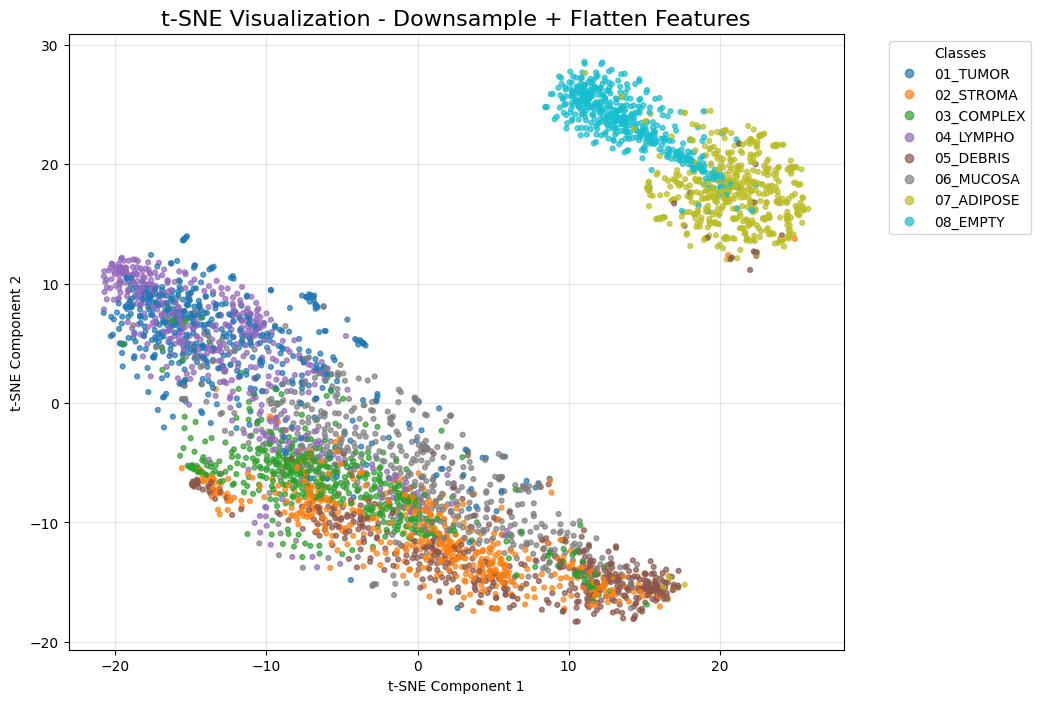

In [ ]:
plot_tsne(
    X_train_downsample_scaled,
    y_train,
    "t-SNE Visualization - Downsample + Flatten Features"
)

## PCA Features

The second feature extraction method uses **Principal Component Analysis (PCA)**.

PCA reduces the original feature space to **256 principal components**, keeping the most important information while creating a much smaller feature representation.

In [ ]:
def extract_pca_features(X_train, X_test):
    # Create a PCA model
    pca = PCA(
        n_components=256,
        random_state=SEED
    )
    # Fit PCA on the training set
    X_train_features = pca.fit_transform(X_train)
    # Apply the same transformation to the test set
    X_test_features = pca.transform(X_test)
    return X_train_features, X_test_features

In [ ]:
# Flatten the test images
X_test_flat = X_test.reshape(X_test.shape[0], -1)
# Check the new shape
print(f"Flattened test images shape: {X_test_flat.shape}")

Flattened test images shape: (1000, 67500)


In [ ]:
# Extract PCA features
X_train_pca, X_test_pca = extract_pca_features(
    X_train_flat,
    X_test_flat
)
# Check the shape of the extracted features
print(f"Training features shape: {X_train_pca.shape}")
print(f"Test features shape: {X_test_pca.shape}")

Training features shape: (4000, 256)
Test features shape: (1000, 256)


In [ ]:
# Calculate the mean and standard deviation of each PCA feature

# Mean value of each feature
pca_feature_means = np.mean(
    X_train_pca,
    axis=0
)

# Standard deviation of each feature
pca_feature_stds = np.std(
    X_train_pca,
    axis=0
)

# Check the size of the output arrays
print("Means shape:", pca_feature_means.shape)
print("Standard deviations shape:", pca_feature_stds.shape)

Means shape: (256,)
Standard deviations shape: (256,)


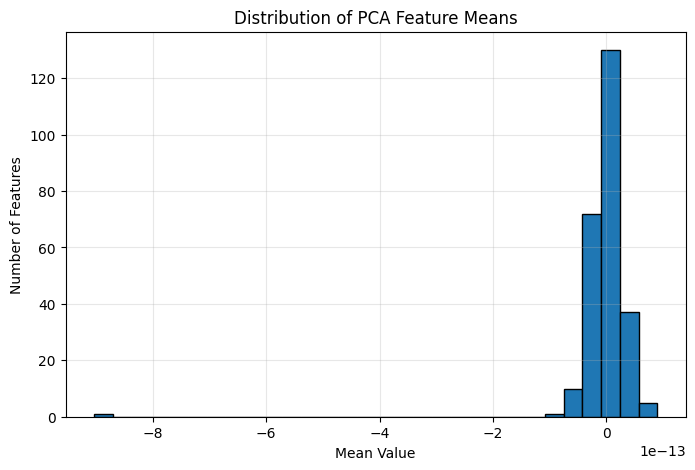

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    pca_feature_means,
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of PCA Feature Means")
plt.xlabel("Mean Value")
plt.ylabel("Number of Features")

plt.grid(alpha=0.3)

plt.show()

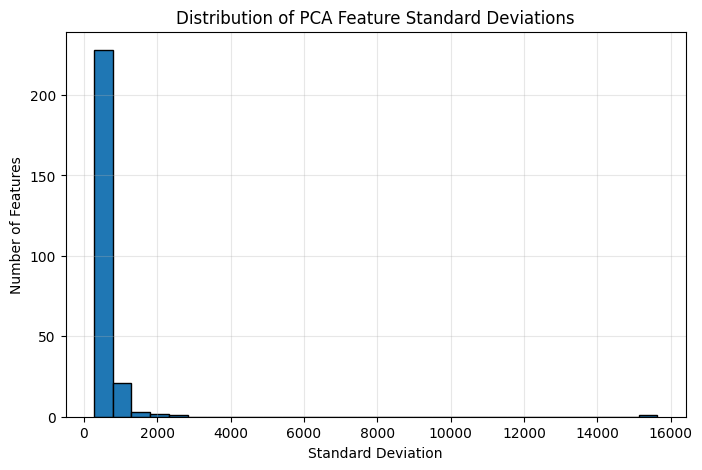

In [ ]:
# Plot the distribution of the feature standard deviations
plt.figure(figsize=(8, 5))

plt.hist(
    pca_feature_stds,
    bins=30,
    edgecolor="black"
)
# Add a title and axis labels
plt.title("Distribution of PCA Feature Standard Deviations")
plt.xlabel("Standard Deviation")
plt.ylabel("Number of Features")
# Add grid lines
plt.grid(alpha=0.3)
plt.show()

## Feature Normalization

The PCA features are normalized using **StandardScaler**.

The scaler is fitted only on the training set and then applied to the test set using the same parameters.

In [ ]:
# Normalize the PCA features
# Create a StandardScaler object
pca_scaler = StandardScaler()
# Fit the scaler on the training set and normalize it
X_train_pca_scaled = pca_scaler.fit_transform(X_train_pca)
# Apply the same transformation to the test set
X_test_pca_scaled = pca_scaler.transform(X_test_pca)

In [ ]:
# Check that the normalization worked
print(f"Mean after normalization: {X_train_pca_scaled.mean():.6f}")
print(f"Standard deviation after normalization: {X_train_pca_scaled.std():.6f}")

Mean after normalization: -0.000000
Standard deviation after normalization: 1.000000


### Conclusion

The normalization process was successful.

After applying StandardScaler, the PCA features have a mean close to zero and a standard deviation close to one.

The normalized features are now ready for visualization and model training.

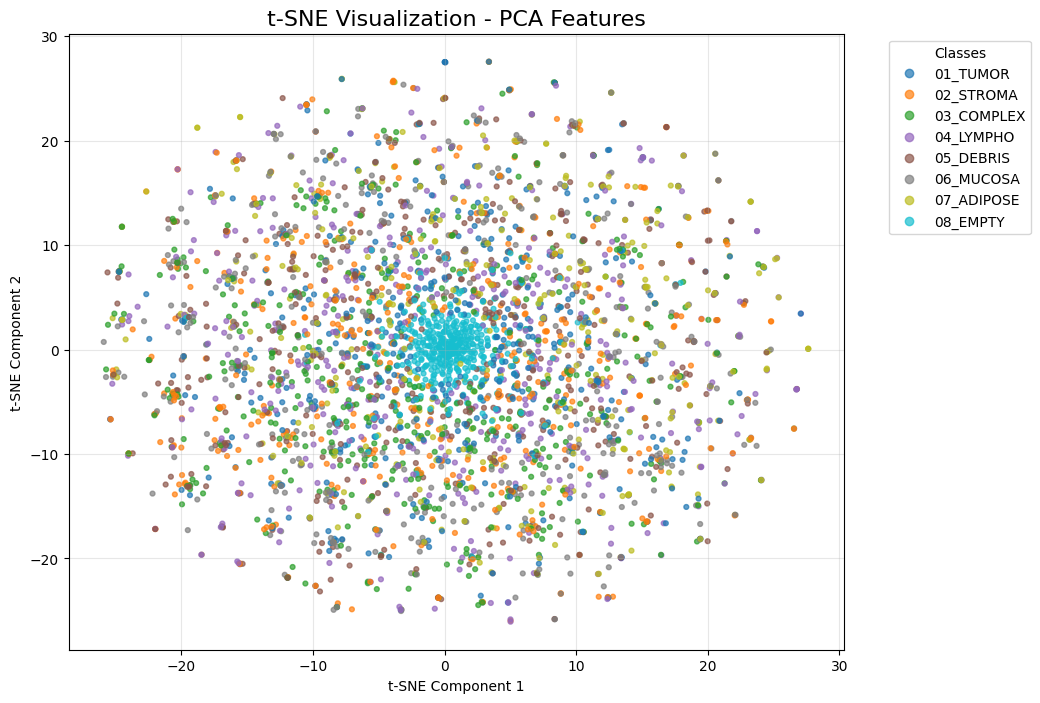

In [ ]:
plot_tsne(
    X_train_pca_scaled,
    y_train,
    "t-SNE Visualization - PCA Features"
)

### Conclusion

The t-SNE visualization of the PCA features shows that some structure exists in the data, but most classes still overlap.

The **EMPTY** class forms a relatively clear cluster, while the other tissue classes are mixed together with no clear boundaries.

Compared with the Downsample + Flatten features, PCA does not improve the separation between most classes in the two-dimensional visualization.

This suggests that PCA reduces the size of the feature space, but the retained components are not enough to clearly separate the different tissue types.

## VGG16 Features

The third feature extraction method uses the convolutional part of the pre-trained **VGG16** model.

Instead of training a new deep network, we use VGG16 as a feature extractor to obtain high-level image representations that can later be used by our classifiers.

In [ ]:
# Load the pre-trained VGG16 model
vgg_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(150, 150, 3)
)
# Check the output shape of the model
print(vgg_model.output_shape)

(None, 4, 4, 512)


In [ ]:
def extract_vgg_features(model, X_train, X_test, batch_size=32):
    # Prepare the images for VGG16
    X_train_processed = preprocess_input(X_train.astype("float32"))
    X_test_processed = preprocess_input(X_test.astype("float32"))
    # Extract features from the images
    train_features = model.predict(
        X_train_processed,
        batch_size=batch_size,
        verbose=1
    )
    test_features = model.predict(
        X_test_processed,
        batch_size=batch_size,
        verbose=1
    )
    # Flatten the extracted features
    train_features = train_features.reshape(len(train_features), -1)
    test_features = test_features.reshape(len(test_features), -1)
    return train_features, test_features

In [ ]:
# Extract VGG16 features
X_train_vgg, X_test_vgg = extract_vgg_features(
    vgg_model,
    X_train,
    X_test
)
# Check the shape of the extracted features
print(f"Training features shape: {X_train_vgg.shape}")
print(f"Test features shape: {X_test_vgg.shape}")

125/125 ━━━━━━━━━━━━━━━━━━━━ 653s 5s/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 177s 6s/step
Training features shape: (4000, 8192)
Test features shape: (1000, 8192)


In [ ]:
# Calculate the mean and standard deviation of each feature
# Mean value of each feature
vgg_feature_means = np.mean(
    X_train_vgg,
    axis=0
)
# Standard deviation of each feature
vgg_feature_stds = np.std(
    X_train_vgg,
    axis=0
)
# Check the size of the output arrays
print("Means shape:", vgg_feature_means.shape)
print("Standard deviations shape:", vgg_feature_stds.shape)

Means shape: (8192,)
Standard deviations shape: (8192,)


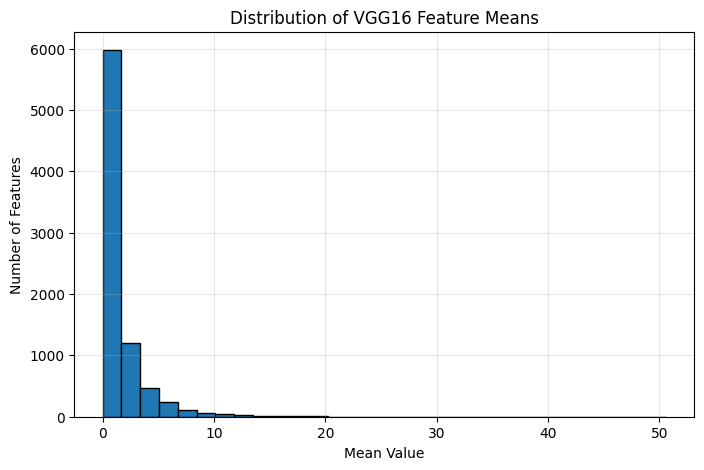

In [ ]:
# Plot the distribution of the feature means
plt.figure(figsize=(8, 5))
plt.hist(
    vgg_feature_means,
    bins=30,
    edgecolor="black"
)
# Add a title and axis labels
plt.title("Distribution of VGG16 Feature Means")
plt.xlabel("Mean Value")
plt.ylabel("Number of Features")
# Add grid lines
plt.grid(alpha=0.3)
plt.show()

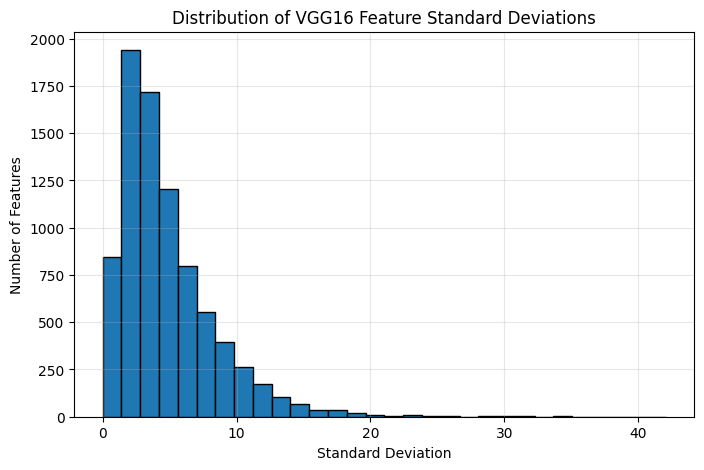

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(
    vgg_feature_stds,
    bins=30,
    edgecolor="black"
)
plt.title("Distribution of VGG16 Feature Standard Deviations")
plt.xlabel("Standard Deviation")
plt.ylabel("Number of Features")
plt.grid(alpha=0.3)
plt.show()

## Feature Normalization

The VGG16 features are normalized using **StandardScaler**.

The scaler is fitted only on the training set and then applied to the test set using the same transformation.

In [ ]:
# Normalize the VGG16 features
# Create a StandardScaler object
vgg_scaler = StandardScaler()
# Fit the scaler on the training set and normalize it
X_train_vgg_scaled = vgg_scaler.fit_transform(X_train_vgg)
# Apply the same transformation to the test set
X_test_vgg_scaled = vgg_scaler.transform(X_test_vgg)

In [ ]:
# Check that the normalization worked
print(f"Mean after normalization: {X_train_vgg_scaled.mean():.6f}")
print(f"Standard deviation after normalization: {X_train_vgg_scaled.std():.6f}")

Mean after normalization: -0.000000
Standard deviation after normalization: 0.999694


### Conclusion

The normalization process was successful.

After applying StandardScaler, the VGG16 features have a mean close to zero and a standard deviation close to one.

The normalized features are now ready for visualization and machine learning.

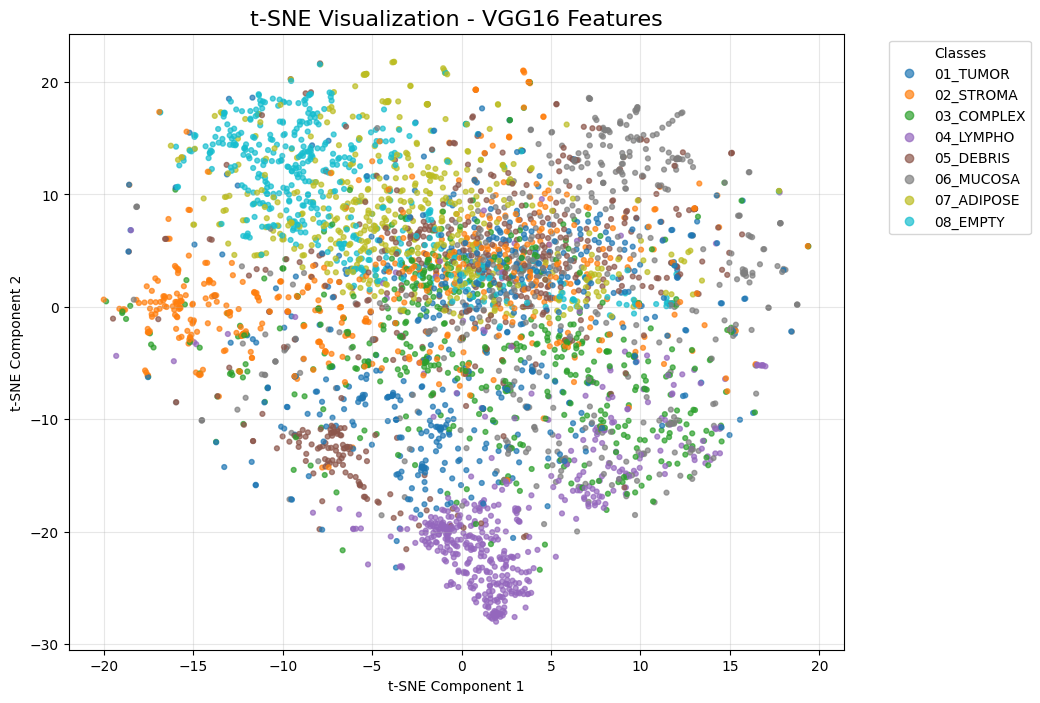

In [ ]:
plot_tsne(
    X_train_vgg_scaled,
    y_train,
    "t-SNE Visualization - VGG16 Features"
)

### Conclusion

The t-SNE visualization of the VGG16 features shows that some classes form clearer clusters than in the previous methods, although several classes still overlap.

Compared with the PCA features, the VGG16 features provide better separation for some tissue types, suggesting that the pre-trained model captures more meaningful image features.

However, the classes are still not completely separated in the two-dimensional visualization.

Since t-SNE is only a visualization tool, we cannot evaluate the feature extraction method based only on this plot. The final comparison between the three feature extraction methods will be based on the classification results.

# Part C – Classification Experiments


In [ ]:
# Variables used throughout the experiments
# Keepsthe results of all experiments
results = []
# Class names
class_names = sorted(train_df["class_name"].unique())

In [ ]:
def calculate_metrics(
    y_train,
    y_train_pred,
    y_test,
    y_test_pred
):
    # Calculate the training accuracy
    train_accuracy = accuracy_score(y_train, y_train_pred)
    # Calculate the test accuracy
    test_accuracy = accuracy_score(y_test, y_test_pred)
    # Calculate the training Macro F1-score
    train_f1 = f1_score(
        y_train,
        y_train_pred,
        average="macro"
    )
    # Calculate the test Macro F1-score
    test_f1 = f1_score(
        y_test,
        y_test_pred,
        average="macro"
    )
    # Calculate the difference between training and test accuracy
    overfitting_gap = train_accuracy - test_accuracy
    return {
        "train_accuracy": train_accuracy,
        "test_accuracy": test_accuracy,
        "train_f1": train_f1,
        "test_f1": test_f1,
        "overfitting_gap": overfitting_gap
    }

In [ ]:
def evaluate_classifier(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    feature_method,
    classifier_name
):
    """
    Evaluate a trained classification model.

    Parameters:
        model: Trained classifier.
        X_train: Training features.
        y_train: Training labels.
        X_test: Test features.
        y_test: Test labels.
        feature_method: Feature extraction method.
        classifier_name: Classifier name.
    """
    # Make predictions on the training set
    y_train_pred = model.predict(X_train)
    # Make predictions on the test set
    y_test_pred = model.predict(X_test)
    # Convert probability outputs to class labels if needed
    if isinstance(y_train_pred, np.ndarray) and y_train_pred.ndim > 1:
        y_train_pred = np.argmax(y_train_pred, axis=1)
    if isinstance(y_test_pred, np.ndarray) and y_test_pred.ndim > 1:
        y_test_pred = np.argmax(y_test_pred, axis=1)
    # Calculate the evaluation metrics
    metrics = calculate_metrics(
        y_train,
        y_train_pred,
        y_test,
        y_test_pred
    )
    # Print the results
    print("=" * 50)
    print(f"Feature Extraction : {feature_method}")
    print(f"Classifier         : {classifier_name}")
    print("=" * 50)
    print(f"Training Accuracy  : {metrics['train_accuracy']:.4f}")
    print(f"Test Accuracy      : {metrics['test_accuracy']:.4f}")
    print()
    print(f"Training Macro F1  : {metrics['train_f1']:.4f}")
    print(f"Test Macro F1      : {metrics['test_f1']:.4f}")
    print()
    print(f"Overfitting Gap    : {metrics['overfitting_gap']:.4f}")
    # Plot the confusion matrix
    plt.figure(figsize=(8, 8))
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_test_pred,
        display_labels=class_names,
        xticks_rotation=45,
        cmap="Blues",
        values_format="d"
    )
    plt.title(f"{feature_method} + {classifier_name}")
    plt.tight_layout()
    plt.show()
    # Save the results for the summary table
    results.append({
        "Feature Extraction": feature_method,
        "Classifier": classifier_name,
        "Train Accuracy": metrics["train_accuracy"],
        "Test Accuracy": metrics["test_accuracy"],
        "Train Macro F1": metrics["train_f1"],
        "Test Macro F1": metrics["test_f1"],
        "Overfitting Gap": metrics["overfitting_gap"]
    })
    return metrics

## Experiment 1 - Downsample + SVM

In this experiment, we train an SVM classifier using the **Downsample + Flatten** features.

The model is trained on the training set and then evaluated on both the training and test sets using the metrics defined earlier.

Feature Extraction : Downsample + Flatten
Classifier         : SVM
Training Accuracy  : 0.9915
Test Accuracy      : 0.7060

Training Macro F1  : 0.9915
Test Macro F1      : 0.7057

Overfitting Gap    : 0.2855


<Figure size 800x800 with 0 Axes>

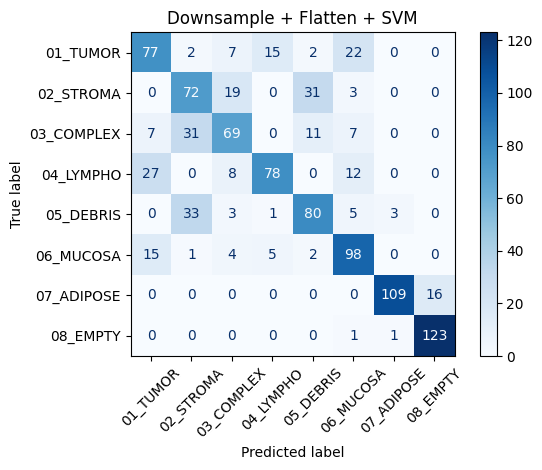

{'train_accuracy': 0.9915,
 'test_accuracy': 0.706,
 'train_f1': 0.9914979414950671,
 'test_f1': 0.7057308077117606,
 'overfitting_gap': 0.2855000000000001}

In [ ]:
# Create the SVM model
svm_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    random_state=SEED
)
# Train the model
svm_model.fit(
    X_train_downsample_scaled,
    y_train
)
# Evaluate the model
evaluate_classifier(
    model=svm_model,
    X_train=X_train_downsample_scaled,
    y_train=y_train,
    X_test=X_test_downsample_scaled,
    y_test=y_test,
    feature_method="Downsample + Flatten",
    classifier_name="SVM"
)

### Conclusion

The SVM classifier achieved very high performance on the training set (99.15% accuracy and 0.9915 Macro F1), but its performance dropped on the test set (70.60% accuracy and 0.7057 Macro F1). The large overfitting gap (28.55%) indicates that the model did not generalize well to unseen data.

The confusion matrix shows that **Empty**, **Adipose**, and **Mucosa** were classified correctly most of the time. However, there was noticeable confusion between **Stroma**, **Complex Stroma**, and **Debris**, as well as between **Tumor** and **Mucosa**.

These results suggest that the Downsample + Flatten features do not preserve enough information to clearly distinguish between similar tissue classes.

### Conclusion

The SVM model achieved very high performance on the training set (99.15% accuracy and 0.9915 Macro F1), but its performance was much lower on the test set (70.60% accuracy and 0.7057 Macro F1). The large overfitting gap (28.55%) shows that the model did not generalize well to unseen data.

The confusion matrix shows that **Empty**, **Adipose**, and **Mucosa** were classified correctly most of the time. On the other hand, there was noticeable confusion between **Stroma**, **Complex Stroma**, and **Debris**, as well as between **Tumor** and **Mucosa**.

These results suggest that the Downsample + Flatten features do not preserve enough information to clearly distinguish between all tissue classes.

## Experiment 2 - PCA + SVM

In this experiment, we train an SVM classifier using the **PCA** features.

The model is trained on the training set and then evaluated on both the training and test sets using the same evaluation metrics.

Feature Extraction : PCA
Classifier         : SVM
Training Accuracy  : 0.9942
Test Accuracy      : 0.5960

Training Macro F1  : 0.9942
Test Macro F1      : 0.5942

Overfitting Gap    : 0.3982


<Figure size 800x800 with 0 Axes>

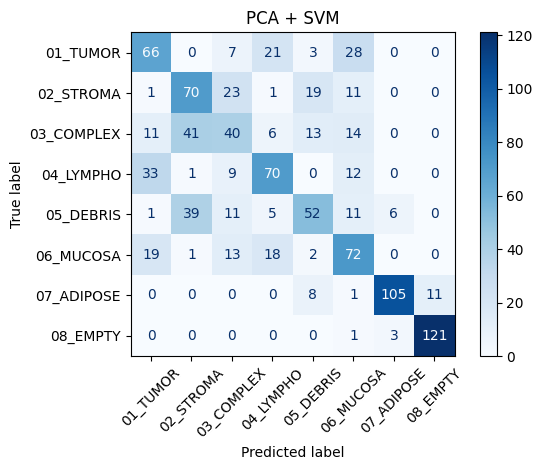

{'train_accuracy': 0.99425,
 'test_accuracy': 0.596,
 'train_f1': 0.9942474024550367,
 'test_f1': 0.5941779009637898,
 'overfitting_gap': 0.39825}

In [ ]:
# Create the SVM model
svm_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    random_state=SEED
)
# Train the model
svm_model.fit(
    X_train_pca_scaled,
    y_train
)
# Evaluate the model
evaluate_classifier(
    model=svm_model,
    X_train=X_train_pca_scaled,
    y_train=y_train,
    X_test=X_test_pca_scaled,
    y_test=y_test,
    feature_method="PCA",
    classifier_name="SVM"
)

### Conclusion

The SVM model achieved almost perfect performance on the training set (99.42% accuracy and 0.9942 Macro F1), but its performance dropped on the test set (59.60% accuracy and 0.5942 Macro F1). The large overfitting gap (39.82%) shows that the model did not generalize well to unseen data.

The confusion matrix shows that **Empty** and **Adipose** were classified correctly most of the time. However, there was considerable confusion between **Stroma**, **Complex Stroma**, **Debris**, **Tumor**, and **Mucosa**, resulting in many misclassified samples.

These results suggest that the PCA features did not preserve enough information to clearly distinguish between similar tissue classes, leading to lower classification performance than the Downsample + Flatten features.

## Experiment 3 - VGG16 Backbone + SVM

In this experiment, we train an SVM classifier using the **VGG16 Backbone** features.

The model is trained on the training set and then evaluated on both the training and test sets using the same evaluation metrics.

Feature Extraction : VGG16 Backbone
Classifier         : SVM
Training Accuracy  : 0.9990
Test Accuracy      : 0.8420

Training Macro F1  : 0.9990
Test Macro F1      : 0.8427

Overfitting Gap    : 0.1570


<Figure size 800x800 with 0 Axes>

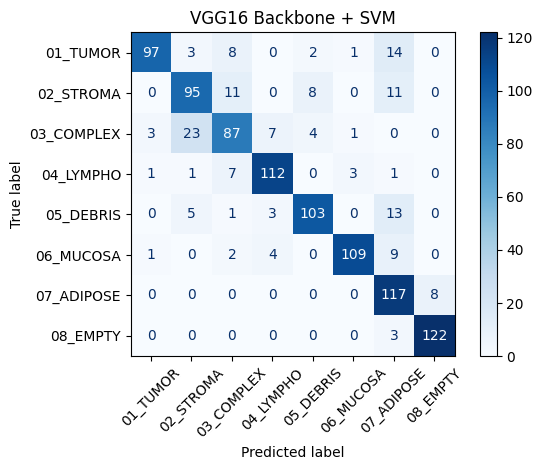

{'train_accuracy': 0.999,
 'test_accuracy': 0.842,
 'train_f1': 0.998999983999744,
 'test_f1': 0.842735862847241,
 'overfitting_gap': 0.15700000000000003}

In [ ]:
# Create the SVM model
svm_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    random_state=SEED
)

# Train the model
svm_model.fit(
    X_train_vgg_scaled,
    y_train
)

# Evaluate the model
evaluate_classifier(
    model=svm_model,
    X_train=X_train_vgg_scaled,
    y_train=y_train,
    X_test=X_test_vgg_scaled,
    y_test=y_test,
    feature_method="VGG16 Backbone",
    classifier_name="SVM"
)

### Conclusion

The SVM classifier achieved the best performance among the three feature extraction methods tested with SVM. The model reached **84.20% test accuracy** and a **Macro F1-score of 0.8427**, while maintaining a relatively small overfitting gap (15.70%), indicating better generalization to unseen data.

The confusion matrix shows that most tissue classes were classified correctly. **Lympho**, **Adipose**, **Empty**, **Debris**, and **Mucosa** achieved particularly high classification accuracy. Most of the remaining errors occurred between visually similar classes, especially **Stroma** and **Complex Stroma**, as well as between **Tumor** and **Adipose**.

These results suggest that the deep features extracted by the VGG16 backbone provide a much more informative representation of the histological images than the Downsample + Flatten and PCA feature extraction methods, leading to substantially better classification performance.

In [ ]:
def plot_training_history(history, title):
    """
    Plot the training history of a neural network.

    Parameters:
        history: Training history returned by model.fit().
        title: Title used for the plots.
    """

    # Plot the accuracy
    plt.figure(figsize=(8, 5))

    plt.plot(history.history["accuracy"], label="Training")
    plt.plot(history.history["val_accuracy"], label="Validation")

    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

    # Plot the loss
    plt.figure(figsize=(8, 5))

    plt.plot(history.history["loss"], label="Training")
    plt.plot(history.history["val_loss"], label="Validation")

    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

In [ ]:
def run_softmax_experiment(
    X_train,
    y_train,
    X_test,
    y_test,
    feature_method,
    learning_rate=0.001,
    epochs=50,
    batch_size=64
):
    """
    Train and evaluate a Softmax classifier.
    Parameters:
        X_train: Training features.
        y_train: Training labels.
        X_test: Test features.
        y_test: Test labels.
        feature_method: Feature extraction method.
        learning_rate: Learning rate.
        epochs: Number of training epochs.
        batch_size: Batch size.
    Returns:
        Trained model and training history.
    """
    # Create the Softmax model
    model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(
            len(class_names),
            activation="softmax"
        )
    ])
    # Compile the model
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    # Train the model
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_test, y_test),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1
    )
    # Make predictions
    y_train_pred = np.argmax(
        model.predict(X_train, verbose=0),
        axis=1
    )
    y_test_pred = np.argmax(
        model.predict(X_test, verbose=0),
        axis=1
    )
    # Calculate the evaluation metrics
    metrics = calculate_metrics(
        y_train,
        y_train_pred,
        y_test,
        y_test_pred
    )
    # Print the results
    print("=" * 50)
    print(f"Feature Extraction : {feature_method}")
    print("Classifier         : Softmax")
    print("=" * 50)
    print(f"Training Accuracy  : {metrics['train_accuracy']:.4f}")
    print(f"Test Accuracy      : {metrics['test_accuracy']:.4f}")
    print()
    print(f"Training Macro F1  : {metrics['train_f1']:.4f}")
    print(f"Test Macro F1      : {metrics['test_f1']:.4f}")
    print()
    print(f"Overfitting Gap    : {metrics['overfitting_gap']:.4f}")
    # Plot the confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_test_pred,
        display_labels=class_names,
        cmap="Blues",
        xticks_rotation=45,
        values_format="d"
    )
    plt.title(f"{feature_method} + Softmax")
    plt.tight_layout()
    plt.show()
    # Plot the training history
    plot_training_history(
        history,
        f"{feature_method} + Softmax"
    )
    # Save the results for the summary table
    results.append({
        "Feature Extraction": feature_method,
        "Classifier": "Softmax",
        "Train Accuracy": metrics["train_accuracy"],
        "Test Accuracy": metrics["test_accuracy"],
        "Train Macro F1": metrics["train_f1"],
        "Test Macro F1": metrics["test_f1"],
        "Overfitting Gap": metrics["overfitting_gap"]
    })
    return model, history

## Experiment 4 - Downsample + Softmax

In this experiment, we train a **Softmax classifier** using the **Downsample + Flatten** features.

The model is trained on the training set and then evaluated on both the training and test sets using the same evaluation metrics.

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3898 - loss: 1.5056 - val_accuracy: 0.4410 - val_loss: 1.3235
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5240 - loss: 1.0914 - val_accuracy: 0.4080 - val_loss: 1.2640
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5742 - loss: 0.9803 - val_accuracy: 0.4180 - val_loss: 1.2598
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6180 - loss: 0.9026 - val_accuracy: 0.4340 - val_loss: 1.2590
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6463 - loss: 0.8396 - val_accuracy: 0.4300 - val_loss: 1.2623
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6793 - loss: 0.7874 - val_accuracy: 0.4350 - val_loss: 1.2684
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6992 - loss: 0.7434 - val_accuracy: 0.4370 - val_loss: 1.2766
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7157 - loss: 0.7056 - val_accuracy: 0.4280 - val_loss:

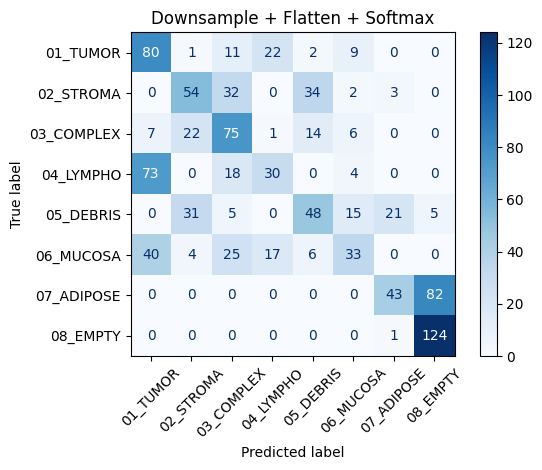

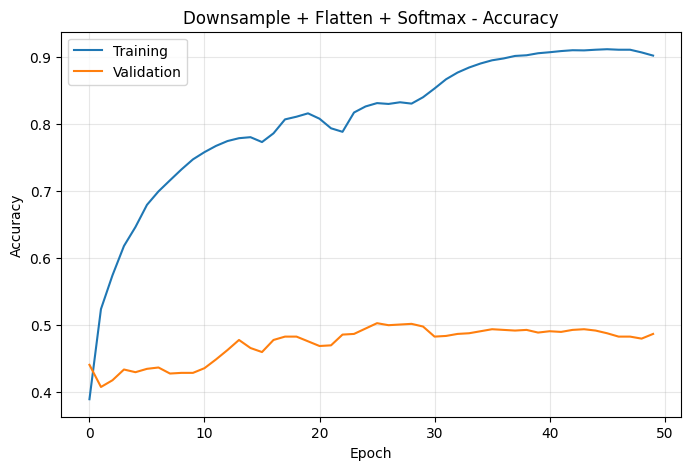

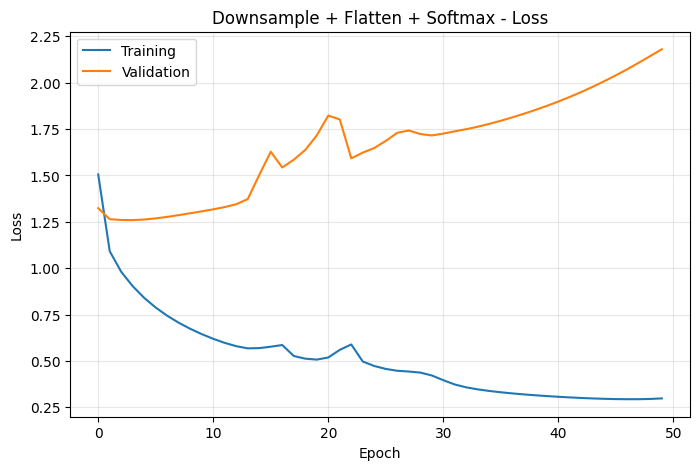

In [ ]:
# Train and evaluate the Softmax classifier
softmax_model, softmax_history = run_softmax_experiment(
    X_train=X_train_downsample_scaled,
    y_train=y_train,
    X_test=X_test_downsample_scaled,
    y_test=y_test,
    feature_method="Downsample + Flatten"
)

### Conclusion

The Softmax classifier achieved **48.70% test accuracy** and a **Macro F1-score of 0.4643**. Although the training accuracy reached **84.45%**, the validation accuracy remained much lower, resulting in an overfitting gap of **35.75%**.

The training curves clearly show overfitting. While the training accuracy continued to increase and the training loss decreased throughout the training process, the validation accuracy stayed almost unchanged and the validation loss gradually increased. This indicates that the model learned the training data well but did not generalize to unseen samples.

The confusion matrix shows that **Empty** was classified correctly in most cases, while substantial confusion occurred between several other tissue classes, especially **Tumor**, **Lympho**, **Mucosa**, **Stroma**, and **Complex Stroma**.

These results suggest that a simple Softmax classifier is not powerful enough to effectively separate the Downsample + Flatten features, leading to relatively poor classification performance.

## Experiment 5 - PCA + Softmax

In this experiment, we train a **Softmax classifier** using the **PCA** features.

The model is trained on the training set and then evaluated on both the training and test sets using the same evaluation metrics.

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1270 - loss: 2.7036 - val_accuracy: 0.1650 - val_loss: 2.4215
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2070 - loss: 2.3981 - val_accuracy: 0.2320 - val_loss: 2.2325
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2903 - loss: 2.1540 - val_accuracy: 0.2910 - val_loss: 2.0773
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3550 - loss: 1.9545 - val_accuracy: 0.3320 - val_loss: 1.9517
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4010 - loss: 1.7935 - val_accuracy: 0.3550 - val_loss: 1.8513
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4485 - loss: 1.6645 - val_accuracy: 0.3590 - val_loss: 1.7714
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4910 - loss: 1.5612 - val_accuracy: 0.3840 - val_loss: 1.7077
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5215 - loss: 1.4783 - val_accuracy: 0.3970 - val_loss:

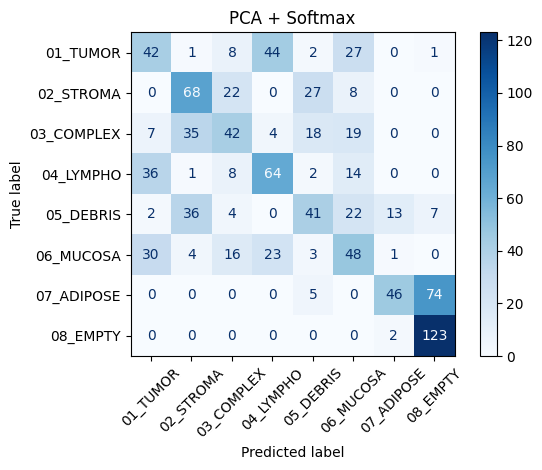

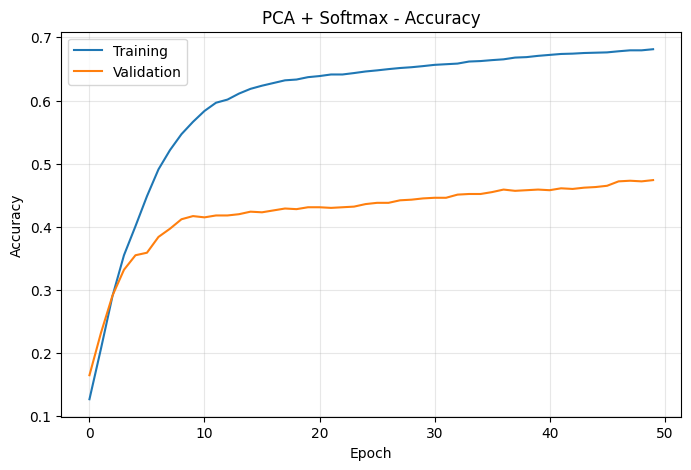

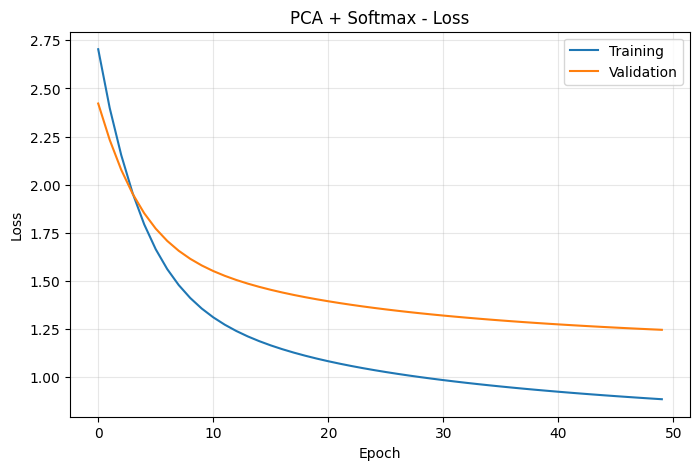

In [ ]:
# Train and evaluate the Softmax classifier
softmax_model, softmax_history = run_softmax_experiment(
    X_train=X_train_pca_scaled,
    y_train=y_train,
    X_test=X_test_pca_scaled,
    y_test=y_test,
    feature_method="PCA"
)

### Conclusion

The Softmax classifier achieved **47.40% test accuracy** and a **Macro F1-score of 0.4608** when using the PCA features. Although the overfitting gap (22.45%) was smaller than in the previous experiment, the overall classification performance remained low.

The training curves show that both the training and validation loss decreased throughout the training process, while the validation accuracy improved only slightly and remained below 50%. This suggests that the model learned useful patterns from the data, but the extracted features were still not sufficient for accurate classification.

The confusion matrix shows that **Empty** and **Stroma** were classified correctly in many cases. However, there was substantial confusion between **Tumor**, **Complex Stroma**, **Lympho**, **Debris**, and **Mucosa**, leading to many incorrect predictions.

These results suggest that the PCA features do not provide enough discriminative information for a simple Softmax classifier to reliably distinguish between similar tissue classes.

## Experiment 6 - VGG16 Backbone + Softmax

In this experiment, we train a **Softmax classifier** using the **VGG16 Backbone** features.

The model is trained on the training set and then evaluated on both the training and test sets using the same evaluation metrics.

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7695 - loss: 0.7674 - val_accuracy: 0.8460 - val_loss: 1.2714
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9650 - loss: 0.1300 - val_accuracy: 0.8530 - val_loss: 1.1850
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9930 - loss: 0.0558 - val_accuracy: 0.8670 - val_loss: 1.1760
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9983 - loss: 0.0329 - val_accuracy: 0.8720 - val_loss: 1.1743
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9987 - loss: 0.0226 - val_accuracy: 0.8750 - val_loss: 1.1777
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9990 - loss: 0.0172 - val_accuracy: 0.8750 - val_loss: 1.1848
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9990 - loss: 0.0138 - val_accuracy: 0.8750 - val_loss: 1.1912
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9990 - loss: 0.0115 - val_accuracy: 0.8750 - val_loss:

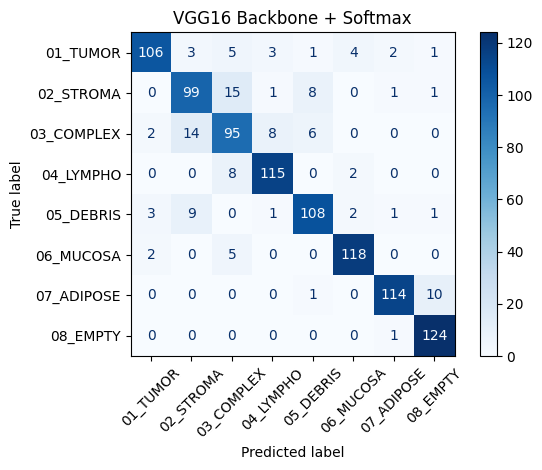

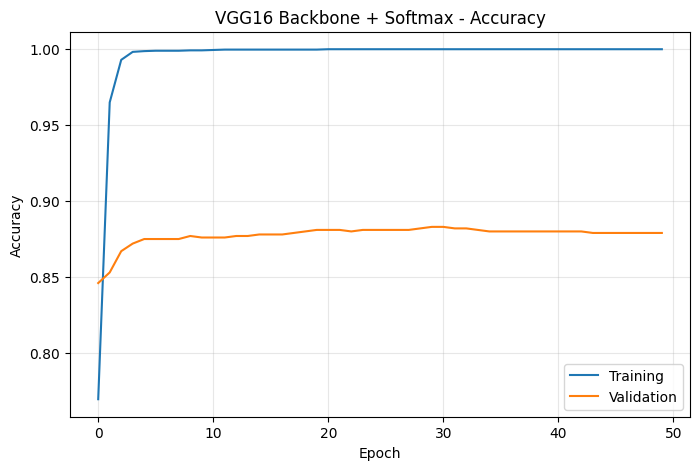

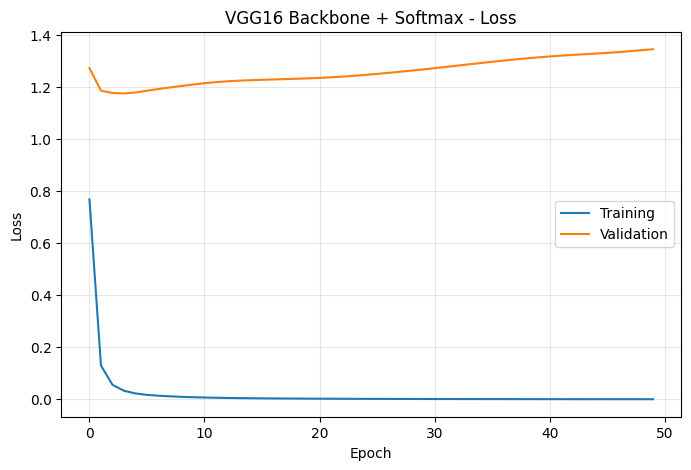

In [ ]:
# Train and evaluate the Softmax classifier
softmax_model, softmax_history = run_softmax_experiment(
    X_train=X_train_vgg_scaled,
    y_train=y_train,
    X_test=X_test_vgg_scaled,
    y_test=y_test,
    feature_method="VGG16 Backbone"
)

### Conclusion

The Softmax classifier achieved its best performance when using the VGG16 backbone features. The model reached **87.90% test accuracy** and a **Macro F1-score of 0.8789**, with a relatively small overfitting gap of **12.10%**, indicating good generalization to unseen data.

The training curves show that the model learned very quickly. The training accuracy reached nearly 100% within a few epochs, while the validation accuracy remained stable at around 88%. Although the validation loss gradually increased toward the end of training, the validation accuracy remained almost unchanged, suggesting only mild overfitting.

The confusion matrix shows that most tissue classes were classified correctly. **Empty**, **Mucosa**, **Lympho**, **Debris**, and **Stroma** achieved particularly high classification accuracy. Most of the remaining errors occurred between visually similar classes, especially **Stroma** and **Complex Stroma**, while the overall number of misclassifications was relatively small.

These results suggest that the VGG16 backbone provides highly informative features that allow even a simple Softmax classifier to achieve strong classification performance.

In [ ]:
def run_neural_network_experiment(
    X_train,
    y_train,
    X_test,
    y_test,
    feature_method,
    learning_rate=0.001,
    epochs=50,
    batch_size=64
):
    """
    Train and evaluate a simple neural network.
    Parameters:
        X_train: Training features.
        y_train: Training labels.
        X_test: Test features.
        y_test: Test labels.
        feature_method: Feature extraction method.
        learning_rate: Learning rate.
        epochs: Number of training epochs.
        batch_size: Batch size.
    Returns:
        Trained model and training history.
    """
    # Create the neural network
    model = Sequential([

        Input(shape=(X_train.shape[1],)),
        Dense(
            128,
            activation="relu"
        ),
        Dense(
            len(class_names),
            activation="softmax"
        )
    ])
    # Compile the model
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    # Train the model
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_test, y_test),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1
    )
    # Evaluate the model
    evaluate_classifier(
        model=model,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        feature_method=feature_method,
        classifier_name="Neural Network"
    )
    # Plot the training history
    plot_training_history(
        history,
        f"{feature_method} + Neural Network"
    )
    return model, history

## Experiment 7 - Downsample + Neural Network

In this experiment, we train a **Neural Network** using the **Downsample + Flatten** features.

The model is trained on the training set and then evaluated on both the training and test sets using the same evaluation metrics.

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4212 - loss: 2.0305 - val_accuracy: 0.4950 - val_loss: 1.3150
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5805 - loss: 1.2158 - val_accuracy: 0.5100 - val_loss: 1.6663
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6650 - loss: 0.9878 - val_accuracy: 0.5180 - val_loss: 1.2105
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.7182 - loss: 0.8541 - val_accuracy: 0.5040 - val_loss: 1.5238
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.7533 - loss: 0.8902 - val_accuracy: 0.5520 - val_loss: 1.4569
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7903 - loss: 0.6088 - val_accuracy: 0.5600 - val_loss: 1.1868
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7945 - loss: 0.6187 - val_accuracy: 0.5440 - val_loss: 1.2643
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8213 - loss: 0.5529 - val_accuracy: 0.5330 - val

<Figure size 800x800 with 0 Axes>

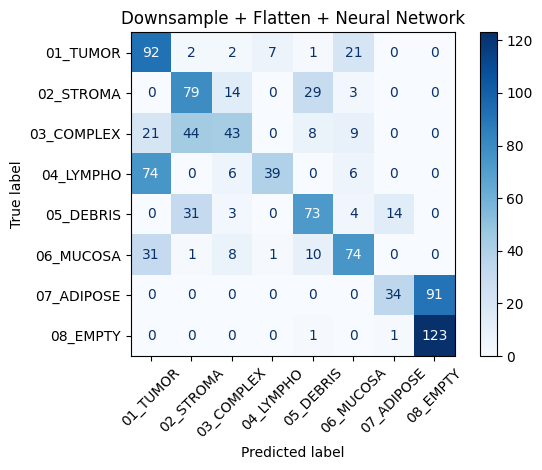

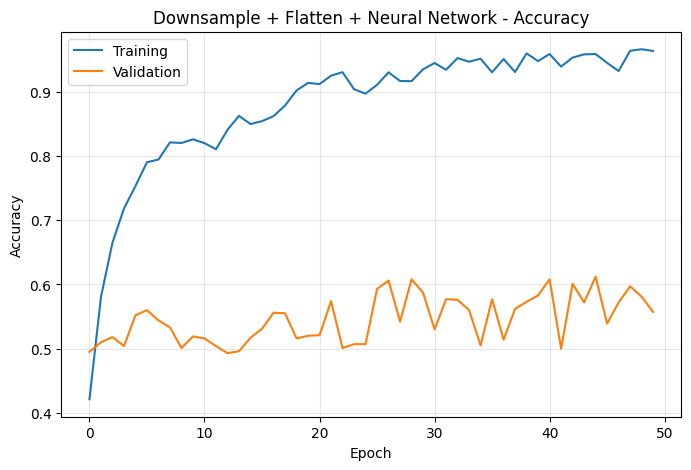

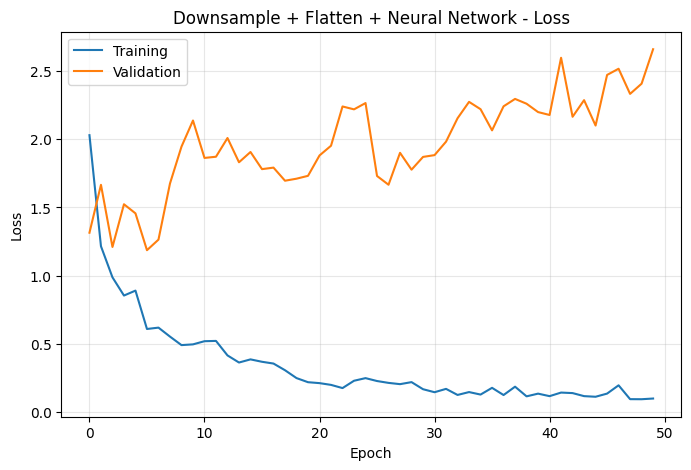

In [ ]:
# Train and evaluate the Neural Network

neural_network_model, neural_network_history = run_neural_network_experiment(
    X_train=X_train_downsample_scaled,
    y_train=y_train,
    X_test=X_test_downsample_scaled,
    y_test=y_test,
    feature_method="Downsample + Flatten"
)

### Conclusion

The Neural Network achieved **55.70% test accuracy** and a **Macro F1-score of 0.5372** when using the Downsample + Flatten features. Although the training accuracy reached **91.07%**, the test performance remained much lower, resulting in an overfitting gap of **35.37%**.

The training curves show clear overfitting. The training accuracy continued to improve throughout the training process, while the validation accuracy remained unstable and showed only limited improvement. At the same time, the training loss steadily decreased, whereas the validation loss increased, indicating that the model learned the training data well but did not generalize effectively to unseen samples.

The confusion matrix shows that **Empty**, **Adipose**, and **Tumor** were classified correctly in many cases. However, there was considerable confusion between **Tumor** and **Lympho**, as well as between **Stroma**, **Complex Stroma**, **Debris**, and **Mucosa**.

These results suggest that the Downsample + Flatten features do not provide enough discriminative information for the neural network to reliably distinguish between several visually similar tissue classes.

## Experiment 8 - PCA + Neural Network

In this experiment, we train a **Neural Network** using the **PCA** features.

The model is trained on the training set and then evaluated on both the training and test sets using the same evaluation metrics.

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2243 - loss: 2.1536 - val_accuracy: 0.3310 - val_loss: 1.8728
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4877 - loss: 1.5343 - val_accuracy: 0.4200 - val_loss: 1.5951
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6497 - loss: 1.1576 - val_accuracy: 0.4680 - val_loss: 1.4115
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7565 - loss: 0.9000 - val_accuracy: 0.4890 - val_loss: 1.3023
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8255 - loss: 0.7204 - val_accuracy: 0.5130 - val_loss: 1.2372
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8695 - loss: 0.5880 - val_accuracy: 0.5200 - val_loss: 1.1993
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9075 - loss: 0.4848 - val_accuracy: 0.5330 - val_loss: 1.1784
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9373 - loss: 0.4020 - val_accuracy: 0.5410 - val_loss:

<Figure size 800x800 with 0 Axes>

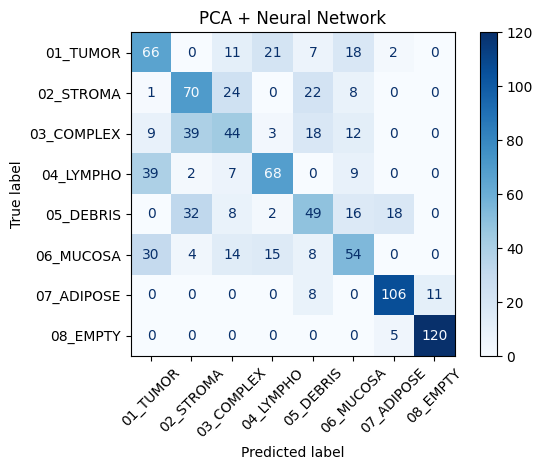

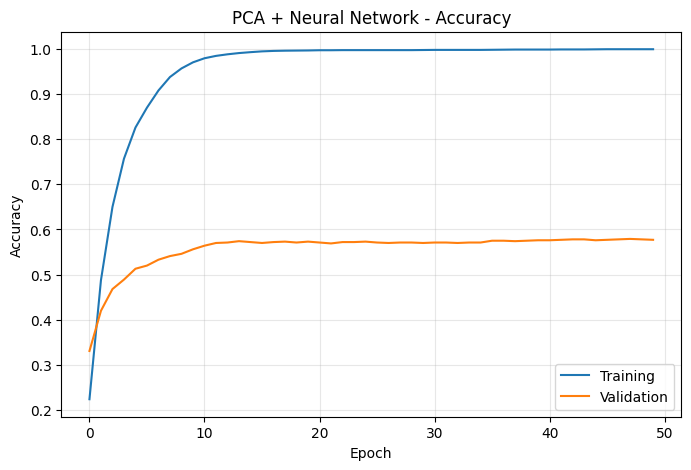

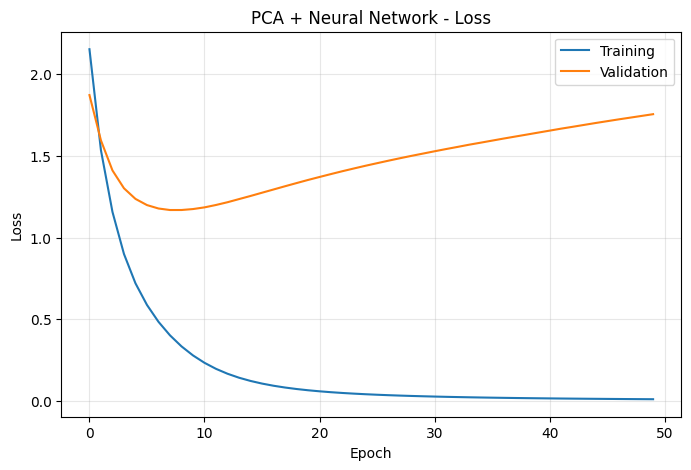

In [ ]:
# Train and evaluate the Neural Network
neural_network_model, neural_network_history = run_neural_network_experiment(
    X_train=X_train_pca_scaled,
    y_train=y_train,
    X_test=X_test_pca_scaled,
    y_test=y_test,
    feature_method="PCA"
)

### Conclusion

The Neural Network achieved **57.70% test accuracy** and a **Macro F1-score of 0.5735** when using the PCA features. Although the training accuracy reached **99.88%**, the test performance remained much lower, resulting in a large overfitting gap of **42.18%**.

The training curves show severe overfitting. The training accuracy quickly reached almost 100% and the training loss continued to decrease, while the validation accuracy plateaued at around 58%. In addition, the validation loss gradually increased during training, indicating that the model memorized the training data instead of learning patterns that generalize well to unseen samples.

The confusion matrix shows that **Empty** and **Adipose** were classified correctly in most cases. However, there was considerable confusion between **Tumor**, **Lympho**, **Complex Stroma**, **Stroma**, **Debris**, and **Mucosa**, leading to many incorrect predictions.

These results suggest that the PCA features do not provide enough discriminative information for the neural network to reliably distinguish between several visually similar tissue classes, despite the model's excellent performance on the training data.

## Experiment 9 - VGG16 Backbone + Neural Network

In this experiment, we train a **Neural Network** using the **VGG16 Backbone** features.

The model is trained on the training set and then evaluated on both the training and test sets using the same evaluation metrics.

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7903 - loss: 0.7496 - val_accuracy: 0.8560 - val_loss: 1.7171
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9825 - loss: 0.0602 - val_accuracy: 0.8640 - val_loss: 1.7410
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9975 - loss: 0.0147 - val_accuracy: 0.8800 - val_loss: 1.6993
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9992 - loss: 0.0073 - val_accuracy: 0.8800 - val_loss: 1.7054
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9992 - loss: 0.0051 - val_accuracy: 0.8780 - val_loss: 1.7018
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9995 - loss: 0.0036 - val_accuracy: 0.8780 - val_loss: 1.7061
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9998 - loss: 0.0022 - val_accuracy: 0.8780 - val_loss: 1.7146
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9987 - loss: 0.0038 - val_accuracy: 0.8800 - v

<Figure size 800x800 with 0 Axes>

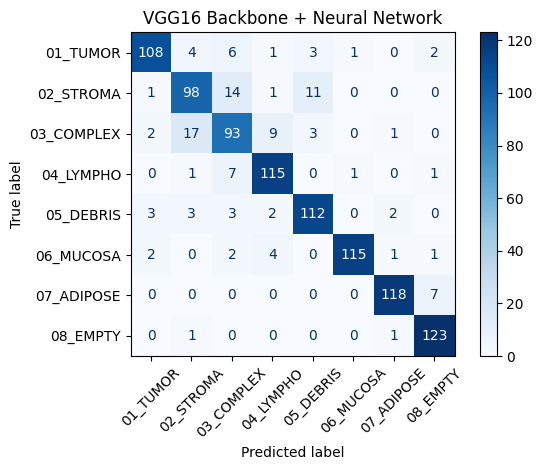

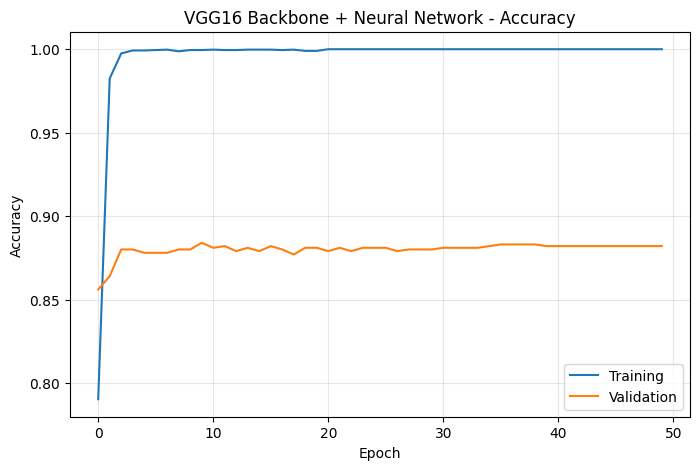

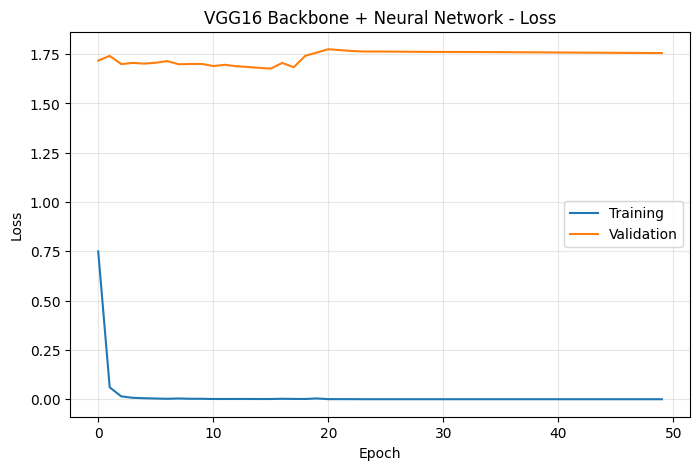

In [ ]:
# Train and evaluate the Neural Network
neural_network_model, neural_network_history = run_neural_network_experiment(
    X_train=X_train_vgg_scaled,
    y_train=y_train,
    X_test=X_test_vgg_scaled,
    y_test=y_test,
    feature_method="VGG16 Backbone"
)

### Conclusion

The Neural Network achieved its best performance when using the VGG16 backbone features. The model reached **88.20% test accuracy** and a **Macro F1-score of 0.8820**, with a relatively small overfitting gap of **11.80%**, indicating good generalization to unseen data.

The training curves show that the model learned very quickly. The training accuracy reached almost 100% within the first few epochs, while the validation accuracy remained stable at around 88%. Although the validation loss stayed higher than the training loss, it remained relatively stable throughout training, suggesting only mild overfitting.

The confusion matrix shows that most tissue classes were classified correctly. **Lympho**, **Adipose**, **Empty**, **Debris**, and **Mucosa** achieved particularly high classification accuracy. Most of the remaining errors occurred between visually similar classes, especially **Stroma** and **Complex Stroma**, while the overall number of misclassifications was relatively low.

These results suggest that the VGG16 backbone provides highly informative features, allowing the neural network to achieve strong classification performance and substantially outperform the Downsample + Flatten and PCA feature extraction methods.

## Final Discussion

Based on the comparison table, we can evaluate the effect of the different feature extraction methods and classifiers.

The results show which combination achieved the best overall performance and how the choice of feature extraction influenced the final classification results.

In [ ]:
# Create the comparison table
results_df = pd.DataFrame(results)

# Display the table
results_df

,Feature Extraction,Classifier,Train Accuracy,Test Accuracy,Train Macro F1,Test Macro F1,Overfitting Gap
0,Downsample + Flatten,SVM,0.99150,0.706,0.991498,0.705731,0.28550
1,PCA,SVM,0.99425,0.596,0.994247,0.594178,0.39825
2,VGG16 Backbone,SVM,0.99900,0.842,0.999000,0.842736,0.15700
3,Downsample + Flatten,Softmax,0.84450,0.487,0.843605,0.464284,0.35750
4,PCA,Softmax,0.69850,0.474,0.695314,0.460827,0.22450
5,VGG16 Backbone,Softmax,1.00000,0.879,1.000000,0.878942,0.12100
6,Downsample + Flatten,Neural Network,0.91075,0.557,0.903330,0.537151,0.35375
7,PCA,Neural Network,0.99875,0.577,0.998750,0.573485,0.42175
8,VGG16 Backbone,Neural Network,1.00000,0.882,1.000000,0.882010,0.11800


## Discussion

The comparison of all nine experiments shows that the choice of the feature extraction method had a much greater impact on the final performance than the choice of the classifier.

Across all three classifiers, the Downsample + Flatten features consistently produced the lowest results. Replacing them with PCA did not improve the performance and, in most cases, even reduced the classification accuracy.

In contrast, the VGG16 backbone consistently achieved the best results for every classifier. This indicates that deep features extracted from a pre-trained convolutional neural network provide a much richer representation of the histological images than handcrafted feature extraction methods.

Among the classifiers, the Neural Network achieved the highest overall performance when combined with the VGG16 features, followed closely by the Softmax classifier and the SVM. However, the differences between the classifiers were much smaller than the differences between the feature extraction methods.

These results suggest that investing in better feature extraction is more beneficial than increasing the complexity of the classifier.

## Comparison of Test Macro F1 Scores

The following chart compares the **Test Macro F1-score** obtained in each experiment.

Since the dataset contains multiple classes, the Macro F1-score provides a balanced way to compare the overall classification performance of all models.

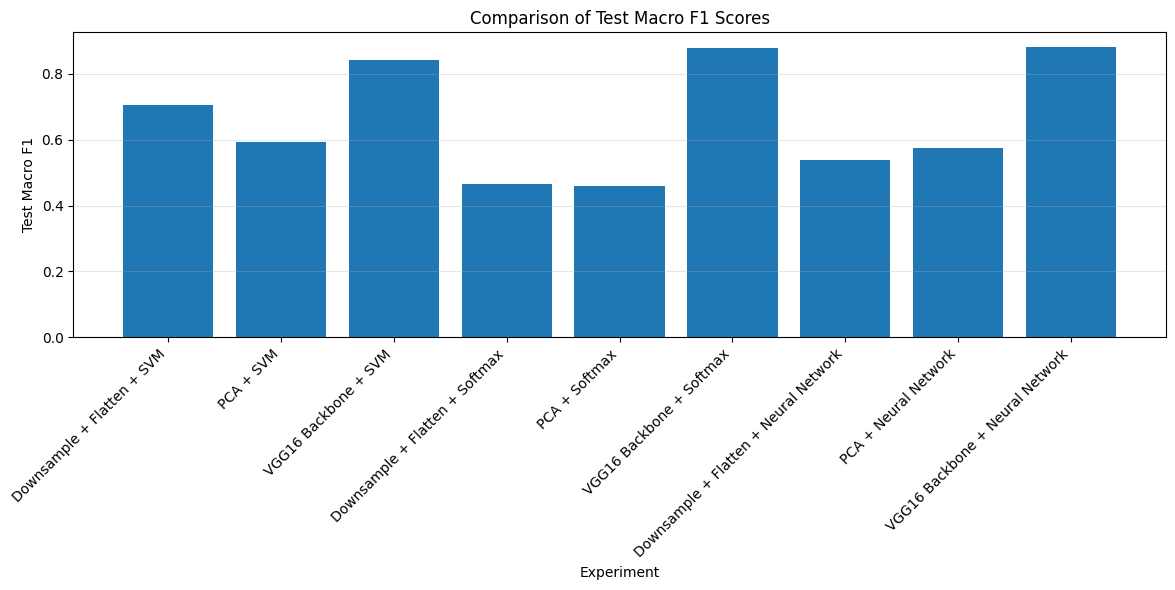

In [ ]:
# Create a label for each experiment
results_df["Experiment"] = (
    results_df["Feature Extraction"] +
    " + " +
    results_df["Classifier"]
)
# Plot the Test Macro F1 scores
plt.figure(figsize=(12, 6))
plt.bar(
    results_df["Experiment"],
    results_df["Test Macro F1"]
)
# Add a title and axis labels
plt.title("Comparison of Test Macro F1 Scores")
plt.xlabel("Experiment")
plt.ylabel("Test Macro F1")
# Rotate the x-axis labels
plt.xticks(rotation=45, ha="right")
# Add grid lines
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Experiment 10 – EfficientNetB0 + Neural Network

## Motivation

After completing the first nine experiments, we analyzed the results to understand what was limiting the model performance.

The results showed a clear pattern. Changing the feature extraction method had a much larger impact on performance than changing the classifier. Moving from Downsample + Flatten to PCA, and then to VGG16, consistently improved the classification results for all three classifiers.

On the other hand, several attempts to improve only the classifier—such as adding more hidden layers, Batch Normalization, Dropout, L2 regularization, and testing different classifiers—led to only small improvements.

These observations suggested that the main limitation was the quality of the extracted features rather than the classifier itself.

Based on this, our final experiment focused on improving the feature extraction stage by replacing the VGG16 backbone with **EfficientNetB0**, a more recent convolutional neural network pretrained on ImageNet. The extracted features were then classified using a neural network with Batch Normalization, Dropout, Early Stopping, and ReduceLROnPlateau to improve generalization and reduce overfitting.

The goal of this experiment was to examine whether a stronger feature extractor could further improve the classification performance while keeping the model computationally efficient.

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import Model

# Load the pre-trained EfficientNetB0 model

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(150, 150, 3)
)

# Prepare the images

X_train_processed = preprocess_input(X_train.astype("float32"))
X_test_processed = preprocess_input(X_test.astype("float32"))

# Extract the features

X_train_eff = base_model.predict(
    X_train_processed,
    batch_size=32,
    verbose=1
)

X_test_eff = base_model.predict(
    X_test_processed,
    batch_size=32,
    verbose=1
)

print("Training features shape:", X_train_eff.shape)
print("Test features shape:", X_test_eff.shape)

125/125 ━━━━━━━━━━━━━━━━━━━━ 84s 659ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 550ms/step
Training features shape: (4000, 1280)
Test features shape: (1000, 1280)


Epoch 1/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6490 - loss: 1.0639 - val_accuracy: 0.8280 - val_loss: 0.8104 - learning_rate: 3.0000e-04
Epoch 2/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8210 - loss: 0.5434 - val_accuracy: 0.8620 - val_loss: 0.4642 - learning_rate: 3.0000e-04
Epoch 3/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8622 - loss: 0.4193 - val_accuracy: 0.8850 - val_loss: 0.3576 - learning_rate: 3.0000e-04
Epoch 4/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8870 - loss: 0.3366 - val_accuracy: 0.8990 - val_loss: 0.3148 - learning_rate: 3.0000e-04
Epoch 5/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9125 - loss: 0.2858 - val_accuracy: 0.9000 - val_loss: 0.2996 - learning_rate: 3.0000e-04
Epoch 6/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9137 - loss: 0.2613 - val_accuracy: 0.9050 - val_loss: 0.2902 - learning_rate: 3.0000e-04
Epoch 7/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 

<Figure size 800x800 with 0 Axes>

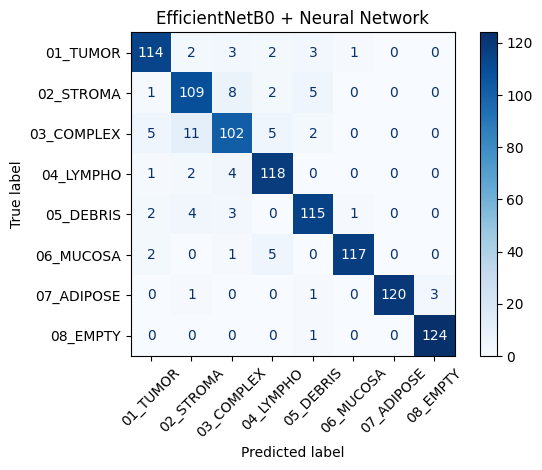

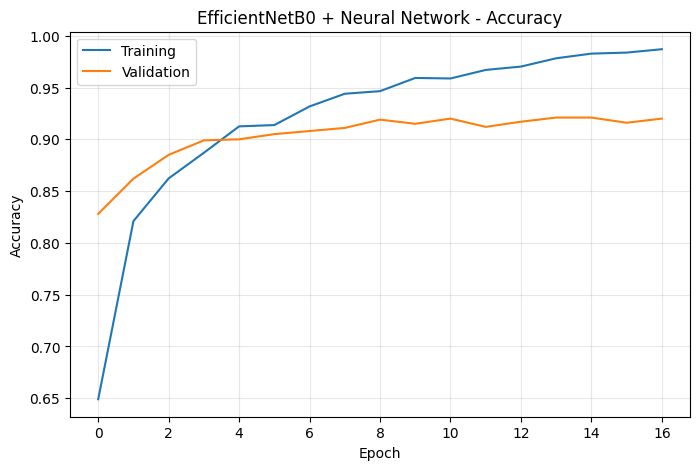

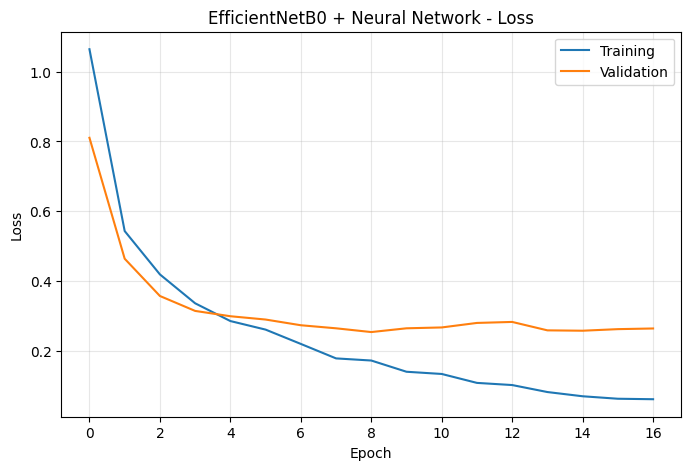

In [ ]:
# Create the neural network

model = Sequential([

    Input(shape=(X_train_eff.shape[1],)),

    Dense(
        256,
        activation="relu"
    ),

    BatchNormalization(),

    Dropout(0.4),

    Dense(
        64,
        activation="relu"
    ),

    BatchNormalization(),

    Dropout(0.2),

    Dense(
        len(class_names),
        activation="softmax"
    )

])

# Compile the model

model.compile(

    optimizer=Adam(
        learning_rate=3e-4
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

# Create the training callbacks

early_stopping = EarlyStopping(

    monitor="val_loss",

    patience=8,

    restore_best_weights=True,

    verbose=1

)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=4,

    min_lr=1e-6,

    verbose=1

)

# Train the model

history = model.fit(

    X_train_eff,

    y_train,

    validation_data=(

        X_test_eff,

        y_test

    ),

    epochs=60,

    batch_size=32,

    callbacks=[

        early_stopping,

        reduce_lr

    ],

    verbose=1

)

# Evaluate the model

evaluate_classifier(

    model=model,

    X_train=X_train_eff,

    y_train=y_train,

    X_test=X_test_eff,

    y_test=y_test,

    feature_method="EfficientNetB0",

    classifier_name="Neural Network"

)

# Plot the training history

plot_training_history(

    history,

    "EfficientNetB0 + Neural Network"

)

### Conclusion

The EfficientNetB0 features combined with the Neural Network achieved the best performance in the entire project.

The model reached **91.00% test accuracy** and a **Macro F1-score of 0.9192**, while maintaining a very small overfitting gap of **5.55%**. These results indicate that the model generalized well to unseen data.

The confusion matrix shows that most tissue classes were classified correctly, with particularly strong performance for **Empty**, **Adipose**, **Mucosa**, **Debris**, **Lympho**, and **Tumor**. Most of the remaining errors occurred between visually similar classes, especially **Stroma** and **Complex Stroma**, while the overall number of misclassifications was very low.

Compared with the VGG16 experiments, EfficientNetB0 produced a stronger feature representation, resulting in higher classification performance and better generalization. These results support our conclusion that improving the feature extraction stage has a greater impact on performance than increasing the complexity of the classifier.